# Option 1 Lab B11 Group 3
Spring 2025 Project by Tarek Alhafez 100064737 for Data Science and AI 

In [10]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
%pip install pandas 
%pip install numpy
%pip install seaborn
%pip install sklearn
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Load the dataset
data = pd.read_csv("Cars_data.csv")


# Data Exploration:



# Basic dataset info


In [13]:
#Getting Number of Columns(Features) and Enteries(Rows)
print("Dataset Shape:", data.shape)


Dataset Shape: (34033, 148)


In [14]:
#Getting an idea of how the data are enteried 
print("\nFirst 5 Rows:\n", data.head(15))



First 5 Rows:
     position                      loc  myear         bt         tt      ft  \
0         11                      NaN   2016        MUV     Manual  Diesel   
1         19         new delhi g.p.o.   2014        SUV     Manual  Diesel   
2         13                SECTOR 39   2020  Hatchback     Manual  Petrol   
3          9                 Dehradun   2018        SUV     Manual  Petrol   
4         12           kandivali west   2017        MUV     Manual  Diesel   
5         19                      NaN   2011        MUV     Manual  Diesel   
6         18                Pune City   2016  Hatchback     Manual  Petrol   
7         18           Bangalore City   2019  Hatchback  Automatic  Petrol   
8          6                      NaN   2018  Hatchback     Manual  Diesel   
9          9            borivali west   2013  Hatchback     Manual  Petrol   
10         1               hsr layout   2017  Hatchback     Manual  Petrol   
11         7                Pune City   2015    

In [15]:
#Getting data types to see if theres format problem and how should catagorical data be encoded or transformed 
print("\nData Types:\n", data.dtypes)



Data Types:
 position               int64
loc                   object
myear                  int64
bt                    object
tt                    object
                      ...   
Unnamed: 143         float64
Unnamed: 144         float64
Unnamed: 145         float64
Unnamed: 146         float64
Fuel Suppy System    float64
Length: 148, dtype: object


In [16]:
#Seeing number of missing values in each column, to see if it needs to be imputed or dropped, depending on the amount of missing values and if we need to column or not
#We can see that some clumn have few missing value, so we can impute them with KNNImputer, as its smarter than just filling with mean or median, as it reads the data and fills it with the most similar values
#We can also see that some columns have a lot of missing values, so we can drop them, as they are not useful for our model
print("\nMissing Values:\n", data.isnull().sum())



Missing Values:
 position                 0
loc                   5251
myear                    0
bt                      18
tt                       0
                     ...  
Unnamed: 143         34033
Unnamed: 144         34033
Unnamed: 145         34033
Unnamed: 146         34033
Fuel Suppy System    34033
Length: 148, dtype: int64


In [17]:

print("\nClass Distribution (tt):\n", data['tt'].value_counts())



Class Distribution (tt):
 tt
Manual       26034
Automatic     7999
Name: count, dtype: int64


For the cell above:
There seem to be an imbalance, we could use SMOTE to make the data more balanced in classification models, by generating synthetic samples for minority class to handle imbalanced datasets.

In [18]:

# Summary statistics for numerical columns
print("\nNumerical Columns Summary:\n", data.describe())


Numerical Columns Summary:
            position         myear            ip      imgCount       modelId  \
count  34033.000000  34033.000000  34033.000000  34033.000000  34033.000000   
mean      12.790115   2015.569565      0.010225     15.590662    813.503217   
std        4.538129      3.779233      0.100604      8.360744    907.644451   
min        1.000000   1983.000000      0.000000      0.000000      3.000000   
25%        9.000000   2013.000000      0.000000     10.000000    262.000000   
50%       13.000000   2016.000000      0.000000     15.000000    582.000000   
75%       17.000000   2018.000000      0.000000     21.000000    838.000000   
max       20.000000   2023.000000      1.000000     53.000000   3417.000000   

       centralVariantId  discountValue            msp        pageNo  \
count      34033.000000   34033.000000   34033.000000  34033.000000   
mean        4245.471013      68.815591      28.178533     76.342609   
std         2454.687987    2754.771227    5198

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34033 entries, 0 to 34032
Columns: 148 entries, position to Fuel Suppy System
dtypes: bool(3), float64(22), int64(28), object(95)
memory usage: 37.7+ MB


This function iterates over the columns and gives there, unique values(how many different values we have for the column), the total number of unique values, the % of null values, and type of data (Numirical or not )

In [20]:
# Enhanced loop to show unique values, their counts, null counts, null percentage, and categorize columns
numerical_cols = []
categorical_cols = []

for col in data.columns:
    unique_vals = data[col].unique()
    num_null = data[col].isnull().sum()
    pct_null = 100 * num_null / len(data)
    dtype = data[col].dtype

    print(f"Column: {col}")
    print(f"  Unique values: {unique_vals[:10]}{' ...' if len(unique_vals) > 10 else ''}")
    print(f"  Number of unique values: {len(unique_vals)}")
    print(f"  Value counts (top 5):")
    print(data[col].value_counts(dropna=False).head())
    print(f"  Null values: {num_null} ({pct_null:.2f}%)")
    print(f"  Dtype: {dtype}")

    if pd.api.types.is_numeric_dtype(data[col]):
        numerical_cols.append(col)
        print("  Category: Numerical")
    else:
        categorical_cols.append(col)
        print("  Category: Categorical")
    print("-" * 40)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print(f"Total numerical columns: {len(numerical_cols)}")
print(f"Total categorical columns: {len(categorical_cols)}")

Column: position
  Unique values: [11 19 13  9 12 18  6  1  7 10] ...
  Number of unique values: 20
  Value counts (top 5):
position
20    2255
11    2248
19    2243
10    2242
18    2241
Name: count, dtype: int64
  Null values: 0 (0.00%)
  Dtype: int64
  Category: Numerical
----------------------------------------
Column: loc
  Unique values: [nan 'new delhi g.p.o.' 'SECTOR 39' 'Dehradun' 'kandivali west'
 'Pune City' 'Bangalore City' 'borivali west' 'hsr layout' 'gurgaon'] ...
  Number of unique values: 508
  Value counts (top 5):
loc
NaN                 5251
Pune City           1904
Gurgaon             1558
Bangalore City      1427
New Delhi G.P.O.    1281
Name: count, dtype: int64
  Null values: 5251 (15.43%)
  Dtype: object
  Category: Categorical
----------------------------------------
Column: myear
  Unique values: [2016 2014 2020 2018 2017 2011 2019 2013 2015 2012] ...
  Number of unique values: 34
  Value counts (top 5):
myear
2017    3534
2018    3310
2014    3171
2015    31

Theres a lot of catagorical features that have many unique values in them which cannot be grouped into common groups, so trying to encode them will rather make the model catch unwanted noise, like columns "loc", "images", 'top_features', 'comfort_features', 'interior_features', 'exterior_features', 'safety_features', 'Color',

For the above loop, i saw a lot of null values columns like:  'template_name_new', 'page_template', 'template_Type_new', 'experiment', 'Unnamed: 132', 'Unnamed: 136', 'Unnamed: 137', 'Unnamed: 138', 'Unnamed: 139', 'Unnamed: 140', 'Unnamed: 141', 'Unnamed: 142', 'Unnamed: 143', 'Unnamed: 144', 'Unnamed: 145', 'Unnamed: 146', 'Fuel Suppy System

Moreover, for duplicate columns theres many, the car model year has a couple of columns, the transimission type has a couple of columns, the same for carType, engine_cc

There seem to be some wrong forms, like pu(which is price), where data are separated by commas
For top speed, accelaration, mileage, torque, and max power, there seem to be a format problem 

Theres many useless columns, like the columns which have links for the car picture, or page number, or id columns, or columns of the car color as they dont help in predicting the cars transmission 

Our label seem to have a imbalance probem as the % of automatic is only 23% which is very low and may make the model not accurate and biased

tt
Manual       26034
Automatic     7999

In [21]:
# List of columns to drop
cols_to_drop = ["loc", "pi", "images", "dvn","model", "variantName" , "vlink", 'price', "msp","userCarId" , "usedCarSkuId", "ucid",
                "sid", "tmGaadiStore", "emiwidget", "leadForm", "leadFormCta", "compare", "brandingIcon", "top_features","comfort_features", "interior_features",
                "exterior_features", "safety_features", "Engine Type", "Value Configuration", "BoreX Stroke", "Front Brake Type", "Rear Brake Type", "model_type_new",
                "originalLocation", "page_title", "compare_car_details", "Seating Capacity" ,"model_year_new" , "car_type_new", "oem_name", "dealer_id_new"
                 , "fuel_type" , "variant_new",  "dynx_event", "dynx_pagetype", "variant_name", "model_year", "dealer_id", "owner_type", "body_type_new" ,
                  "Compression Ratio" , "Unnamed: 132" , "experiment", "template_Type_new", "page_template", "template_name_new", "page_type", "vehicle_type_new",
                  "car_segment" , "fuel_type_new", "model_name", "vid", "offers", "model_new" , "Compression Ratio", "engine_cc", "utype", "body_type_new",
                  "transmissionType","transmission_type","Ground Clearance Unladen", "city_y","city_name_new", "city_x","brand_new", "exterior_color",
                  "oem", "Color","ip", "pageType", "state", "dynx_totalvalue_x", "dynx_totalvalue_y", "state", "city_id_new ", "ip",
                   "Fuel Suppy System", "Unnamed: 146", "Unnamed: 145", "Unnamed: 144", "Unnamed: 143", "Unnamed: 142", "Unnamed: 141","Unnamed: 140", "Unnamed: 139", "Unnamed: 138", "Unnamed: 137", "Unnamed: 136"]   # Replace with your column names

for col in cols_to_drop:
    if col in data.columns:
        data = data.drop(columns=[col])

Data Visualization:

In [22]:
import pandas as pd

# Assuming 'data' is your DataFrame
numerical_data = data.select_dtypes(include=['float64', 'int64', 'bool', 'int32', 'float32'])

# Display the resulting DataFrame with only numerical columns
print("Numerical Columns:\n", numerical_data.columns)
print("\nNumerical Data Preview:\n", numerical_data.head())

Numerical Columns:
 Index(['position', 'myear', 'imgCount', 'threesixty', 'modelId',
       'centralVariantId', 'discountValue', 'pageNo', 'views', 'usedCarId',
       'dynx_itemid_x', 'dynx_itemid2_x', 'corporateId', 'Displacement',
       'No of Cylinder', 'Values per Cylinder', 'No Door Numbers',
       'seating_capacity_new', 'model_id_new', 'city_id_new',
       'max_engine_capacity_new', 'km_driven', 'used_carid', 'dynx_itemid_y',
       'dynx_itemid2_y', 'min_engine_capacity_new'],
      dtype='object')

Numerical Data Preview:
    position  myear  imgCount  threesixty  modelId  centralVariantId  \
0        11   2016        10       False      368              2277   
1        19   2014        21       False      570              8182   
2        13   2020        15       False     3078              7251   
3         9   2018        21        True      245              6429   
4        12   2017        15       False      592              5635   

   discountValue  pageNo  views

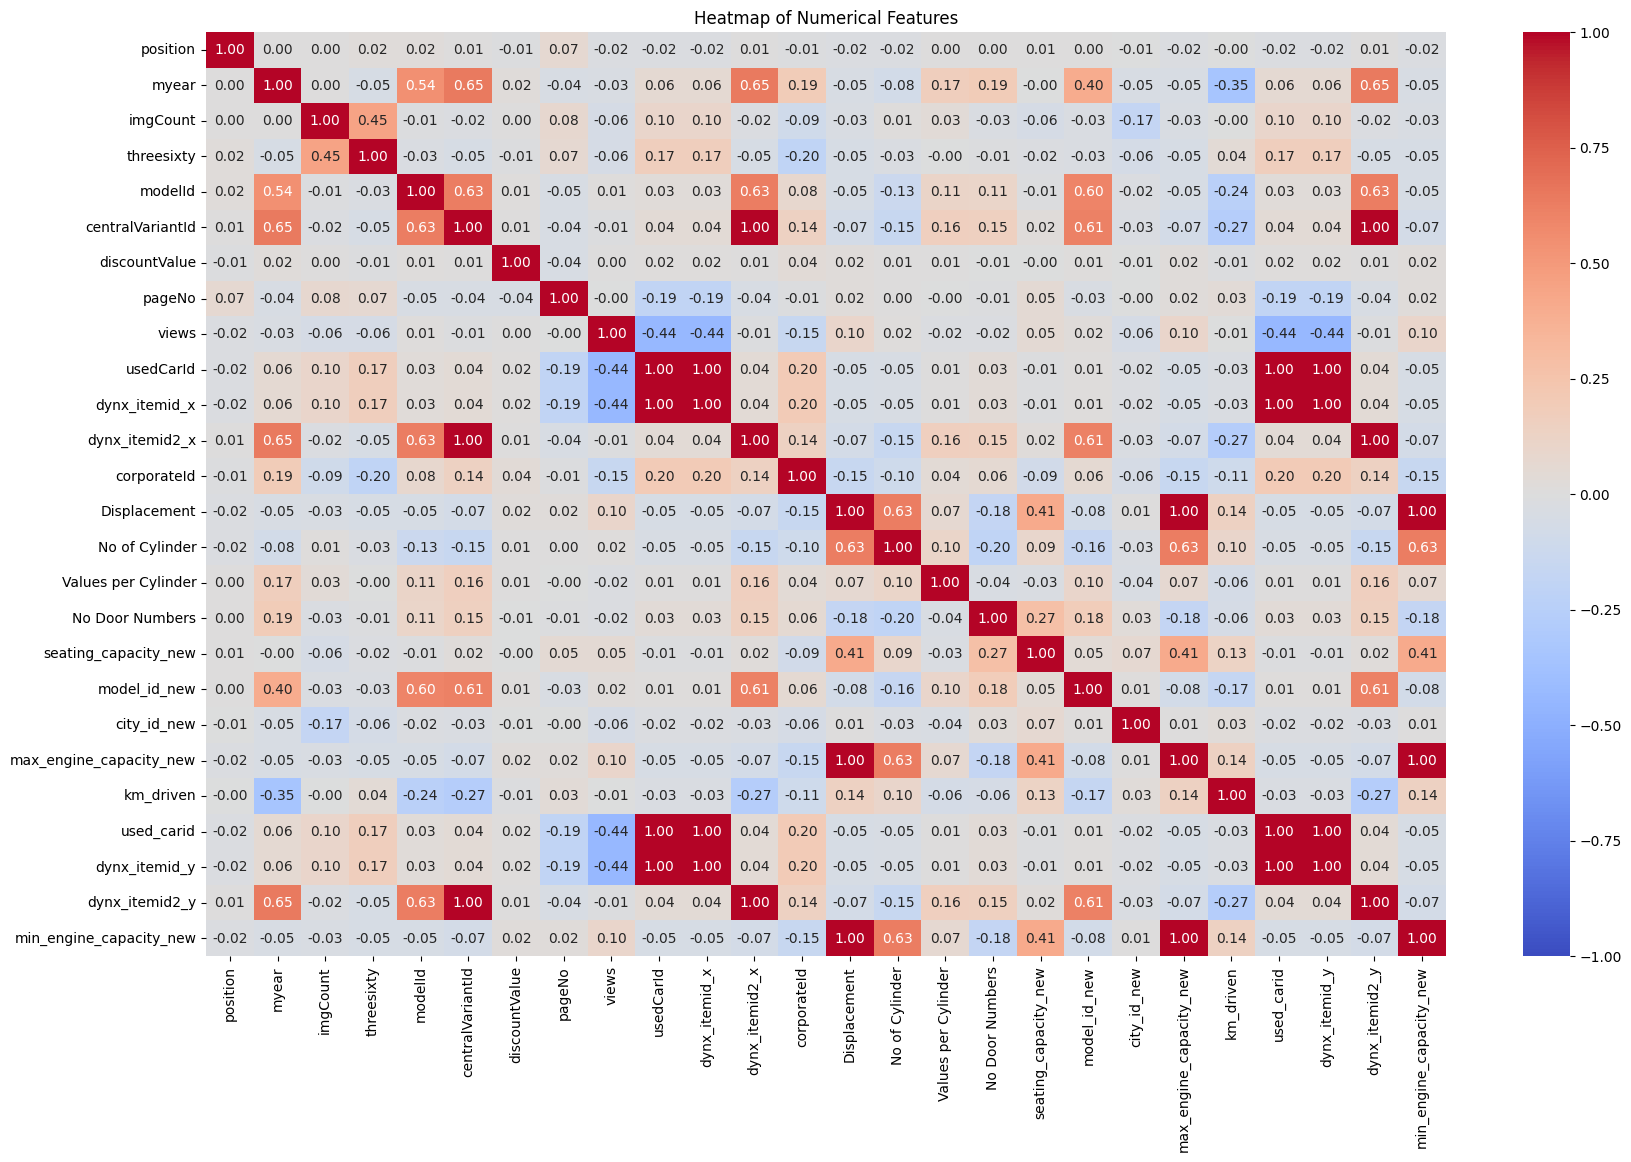

In [23]:
# Compute the correlation matrix
corr_matrix = numerical_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap of Numerical Features")
plt.show()

There seem to be highly correlated data outside the main diagonal which is maybe from being duplicates, like dynx_itemid2_y and centralVariant, and min_engine_capacity_new and max_engine_capacity_new

Displacment and Number of cylinder are highly positvly correlated, and thats normal , as a car has more cylinder the engine size increase 

Numerical Columns:
['position', 'myear', 'imgCount', 'modelId', 'centralVariantId', 'discountValue', 'pageNo', 'views', 'usedCarId', 'dynx_itemid_x', 'dynx_itemid2_x', 'corporateId', 'Displacement', 'No of Cylinder', 'Values per Cylinder', 'No Door Numbers', 'seating_capacity_new', 'model_id_new', 'city_id_new', 'max_engine_capacity_new', 'km_driven', 'used_carid', 'dynx_itemid_y', 'dynx_itemid2_y', 'min_engine_capacity_new']


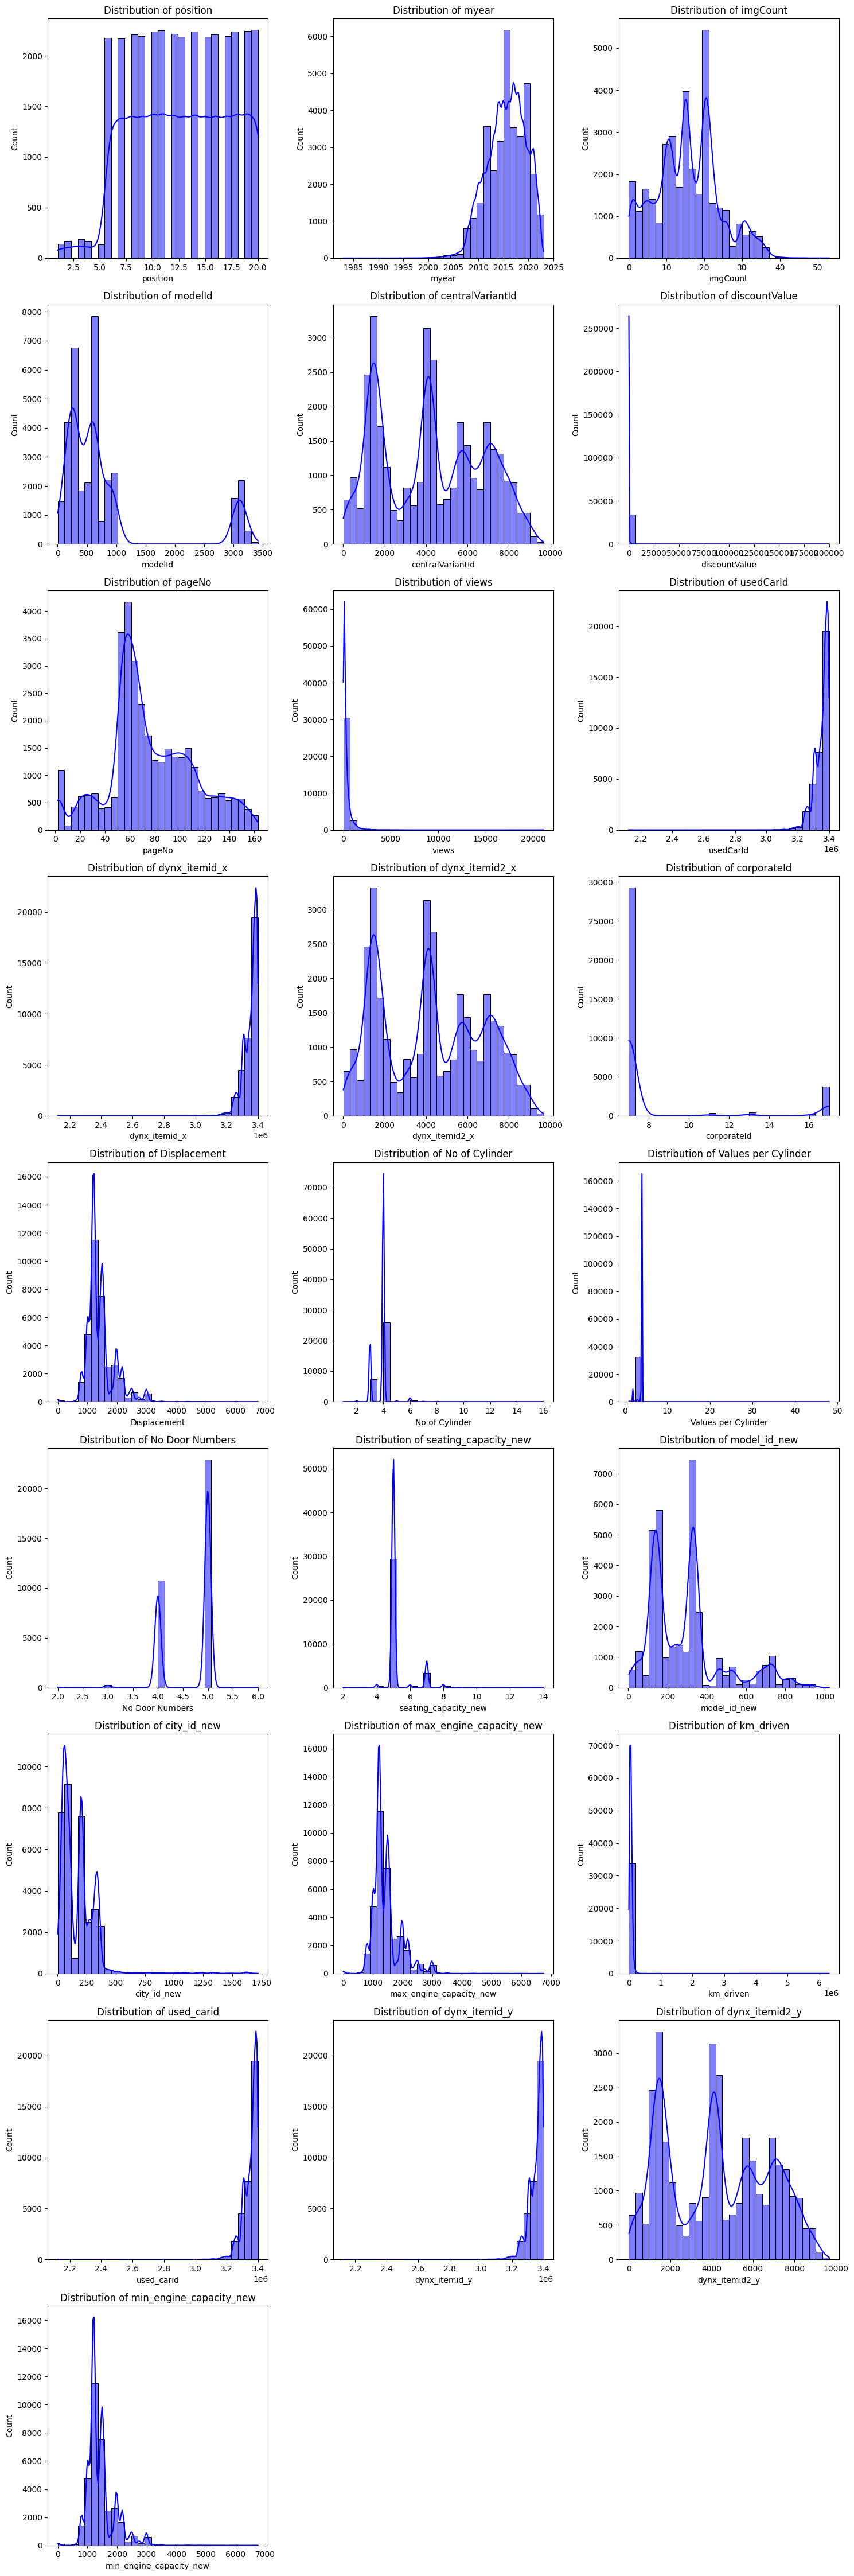

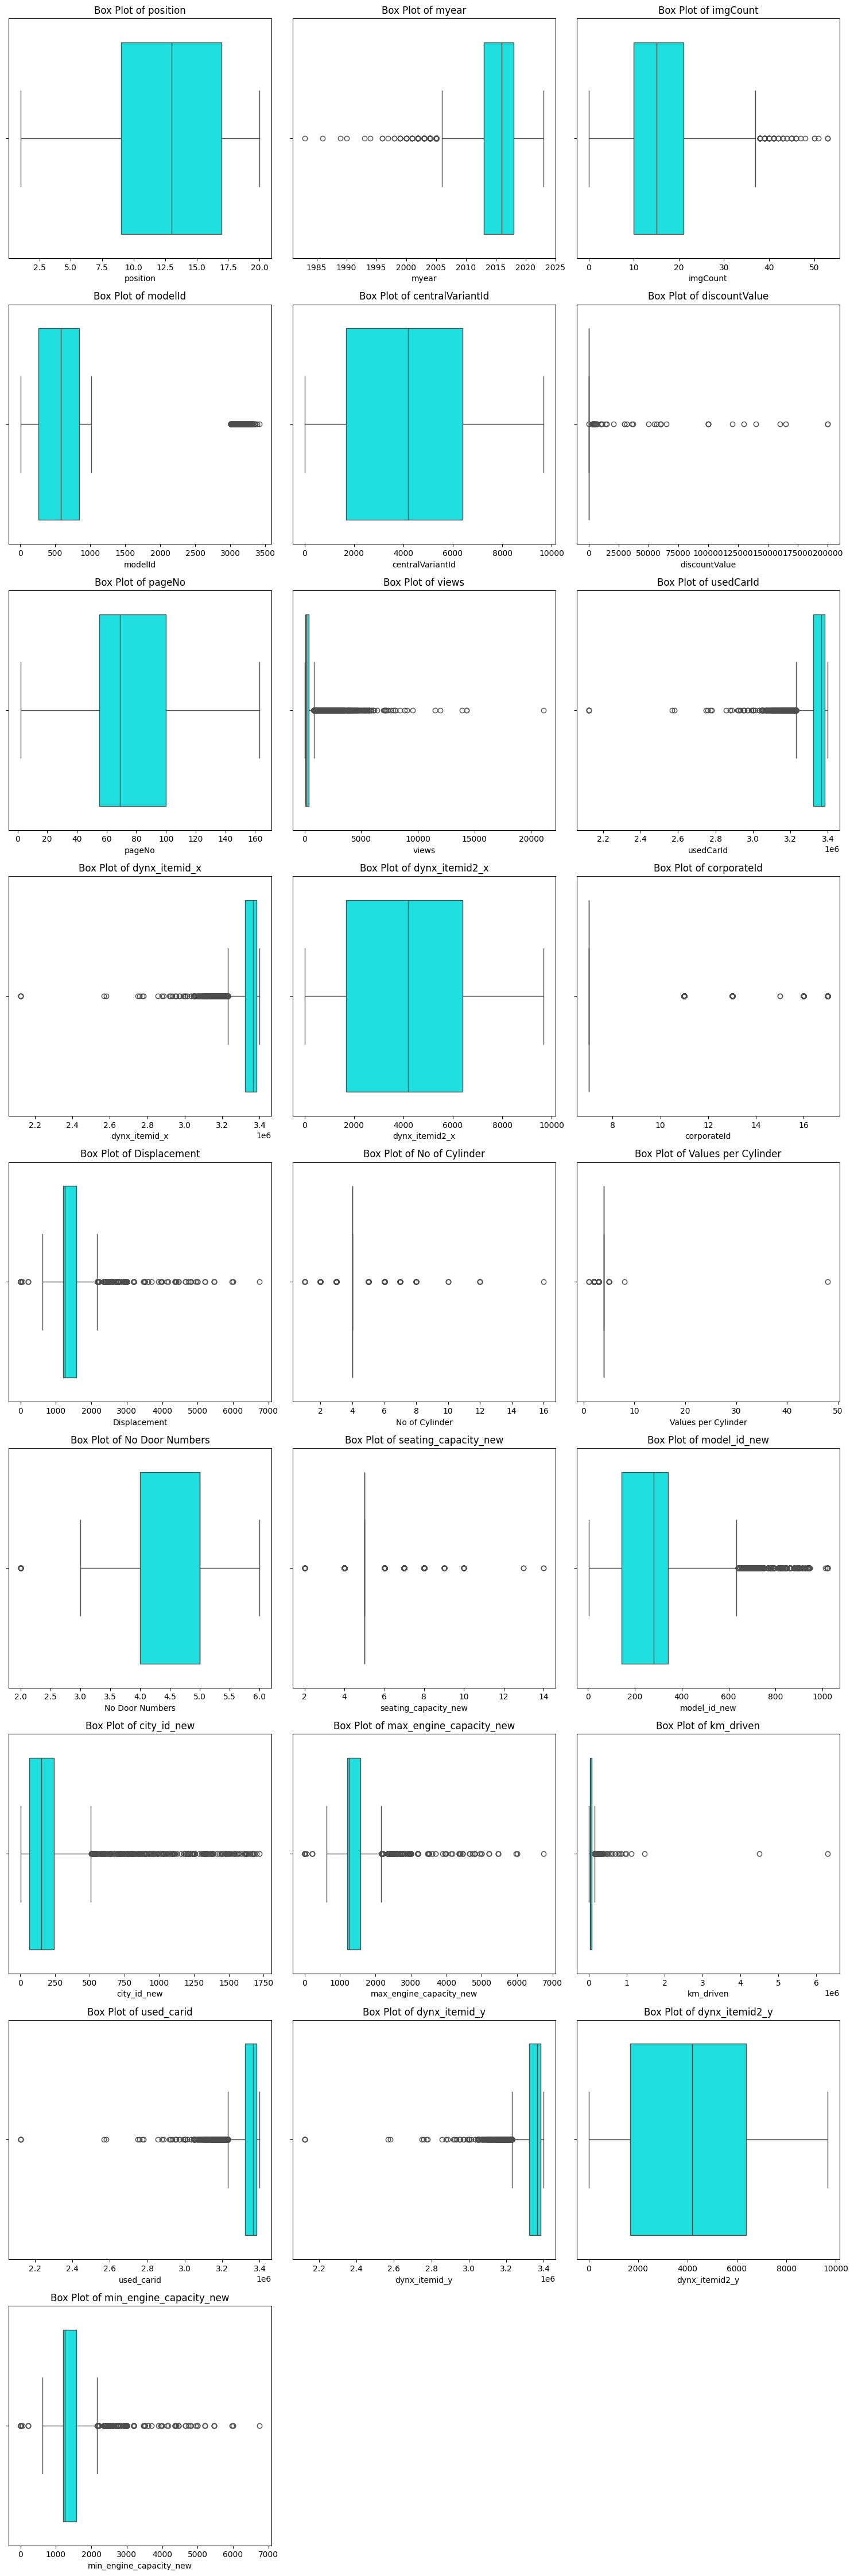

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (excluding boolean columns)
# Use select_dtypes to filter numeric columns (int, float) and exclude bool
numerical_data = data.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

# Print the numerical columns
print("Numerical Columns:")
print(numerical_data.columns.tolist())

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_data.columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# --- BOX PLOTS ---
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

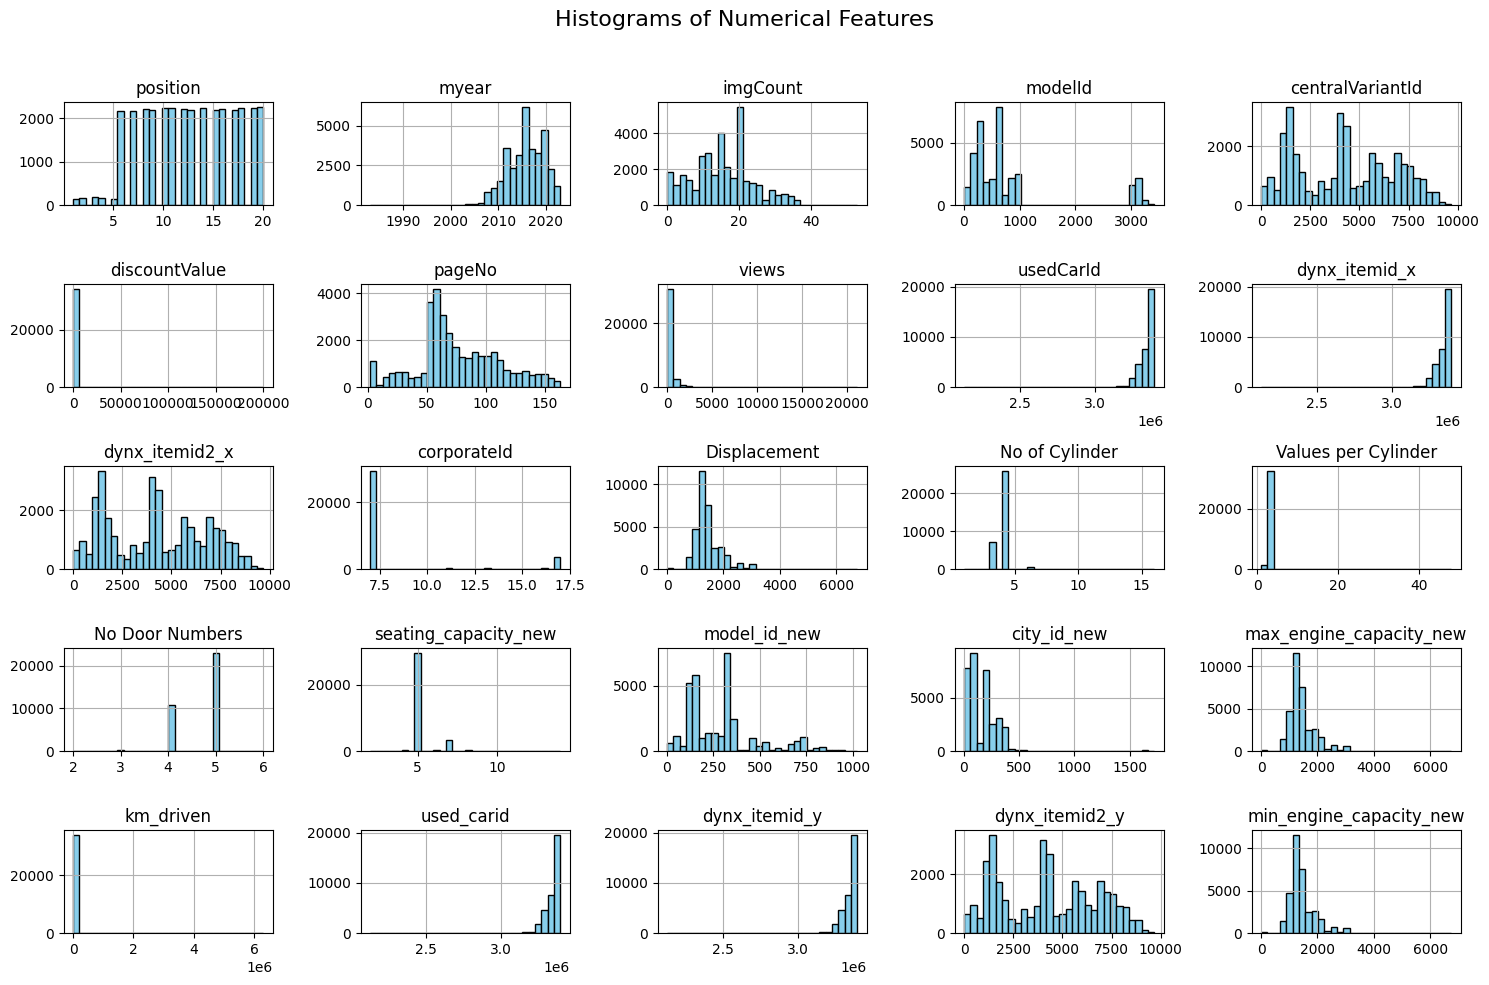

In [25]:
# Plot histograms for all numerical columns
numerical_data.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

For columns position, coperateId, imgCount, used_carid and discountValue they dont add any meaning while predicting car transimmision, as you cant extract from them will a car have a manual or automatic, so will drop them



In [26]:
# List of columns to drop
cols_to_drop = [
    "position", "omperateId", "imgCount", "discountValue", "used_carid"
]

for col in cols_to_drop:
    if col in data.columns:
        data = data.drop(columns=[col])



C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


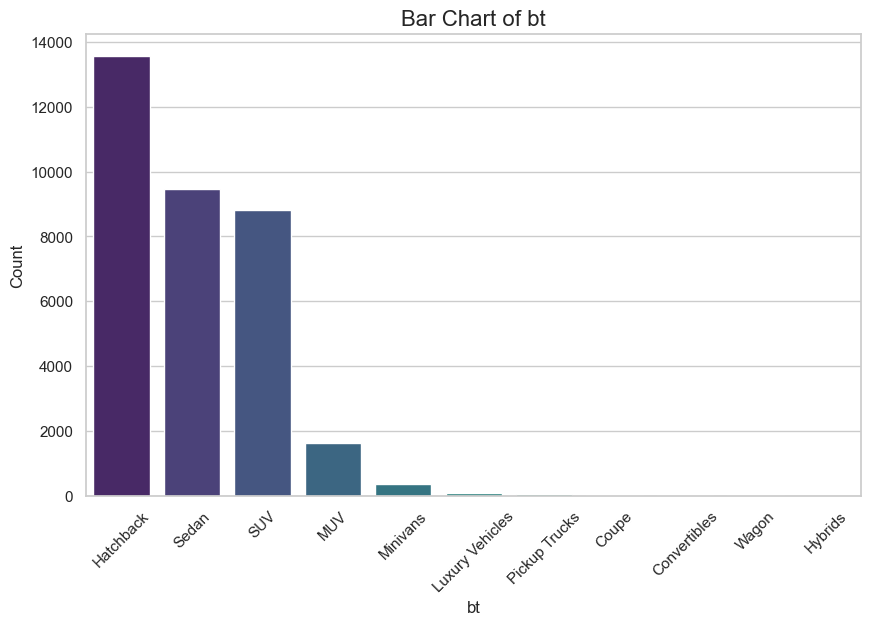

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


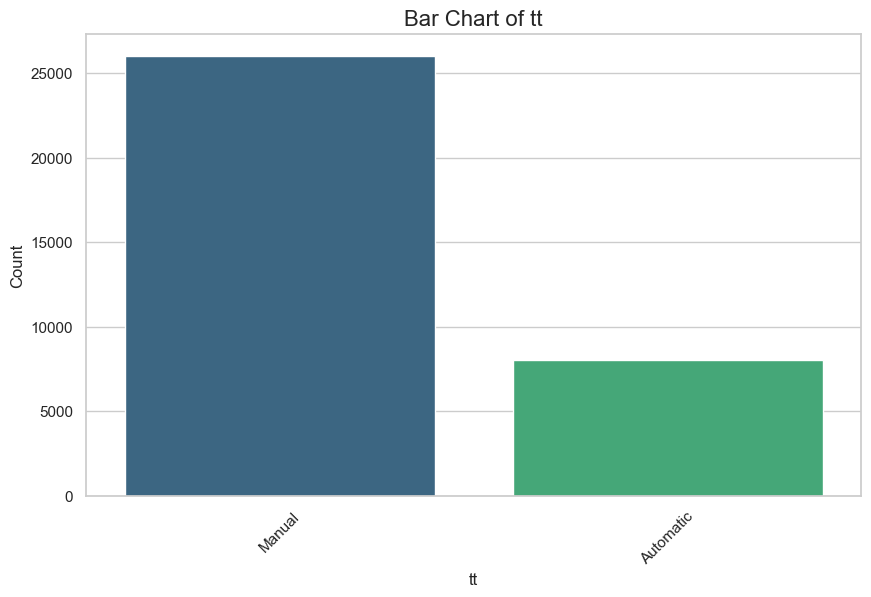

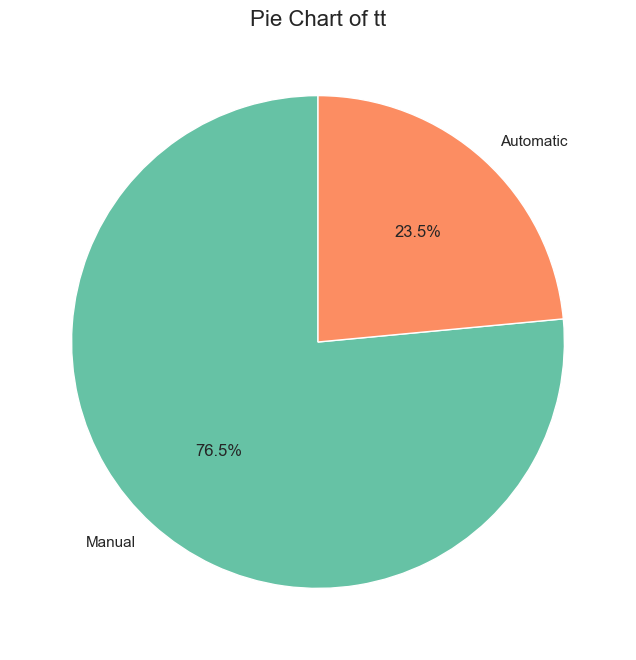

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


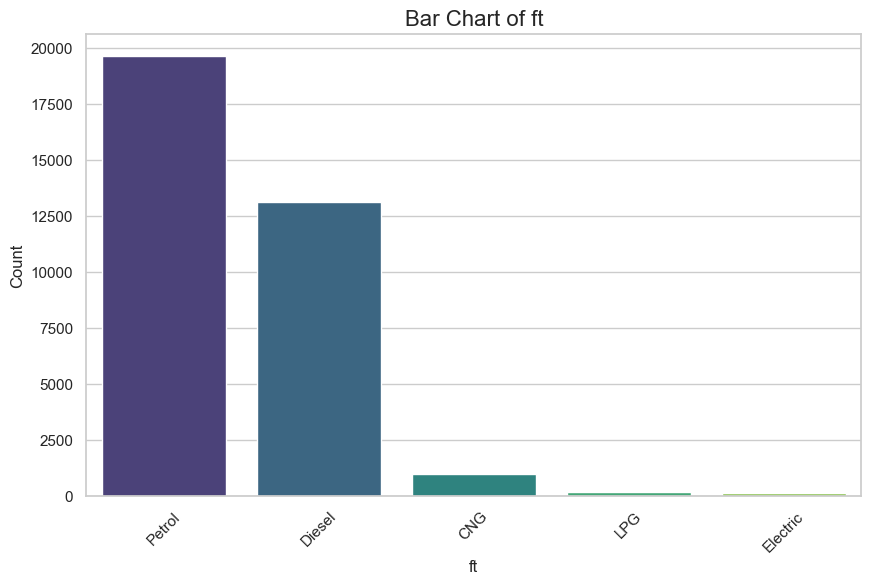

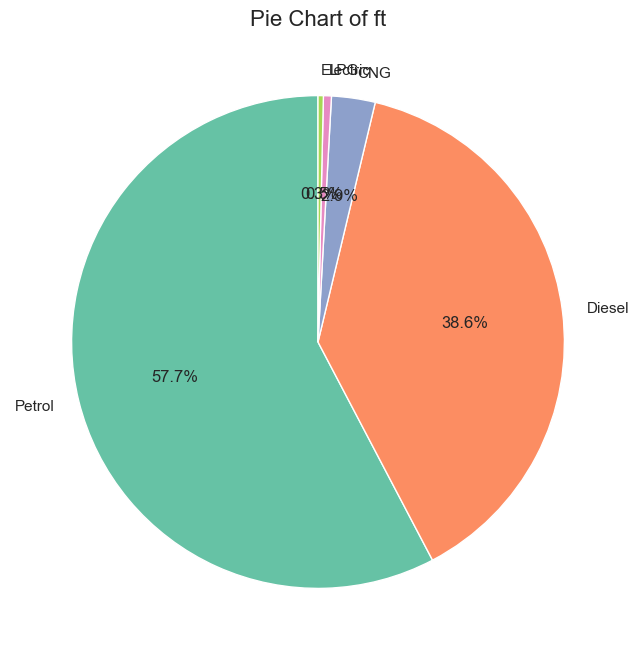

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


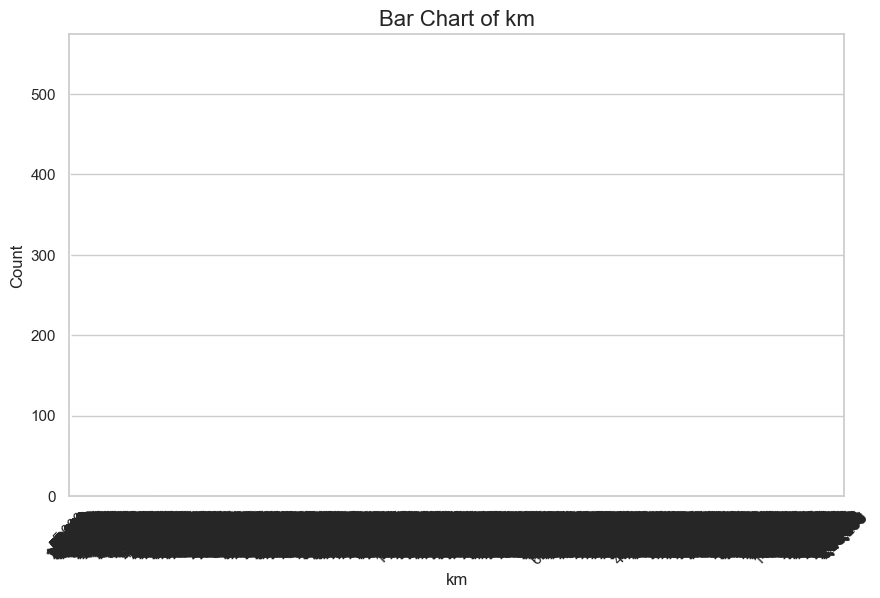

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


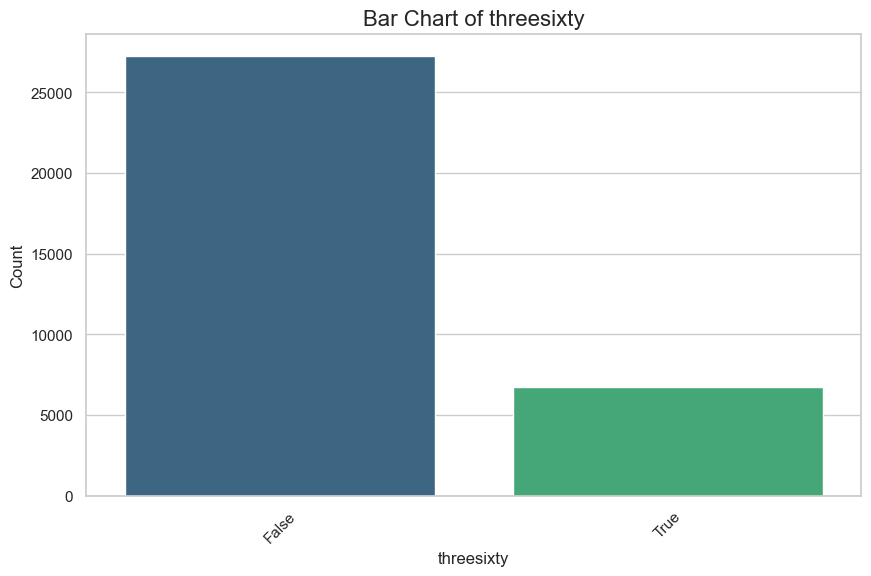

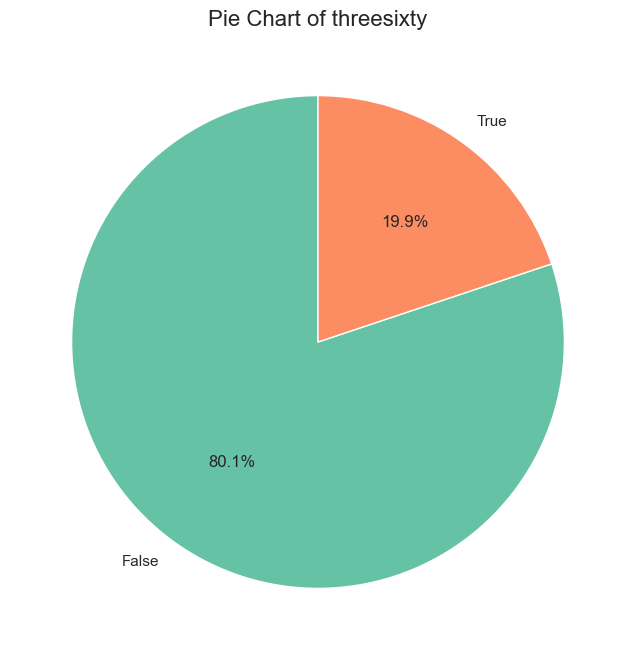

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


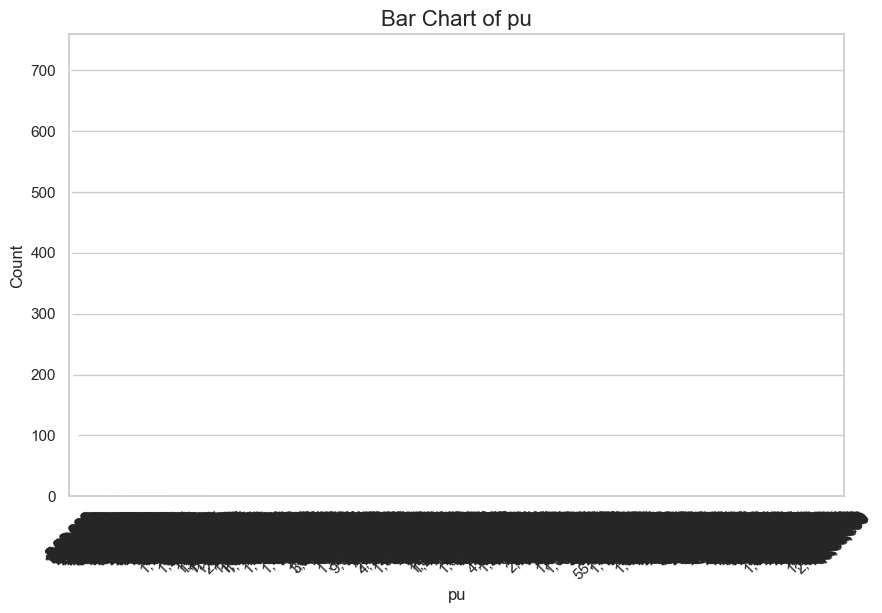

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


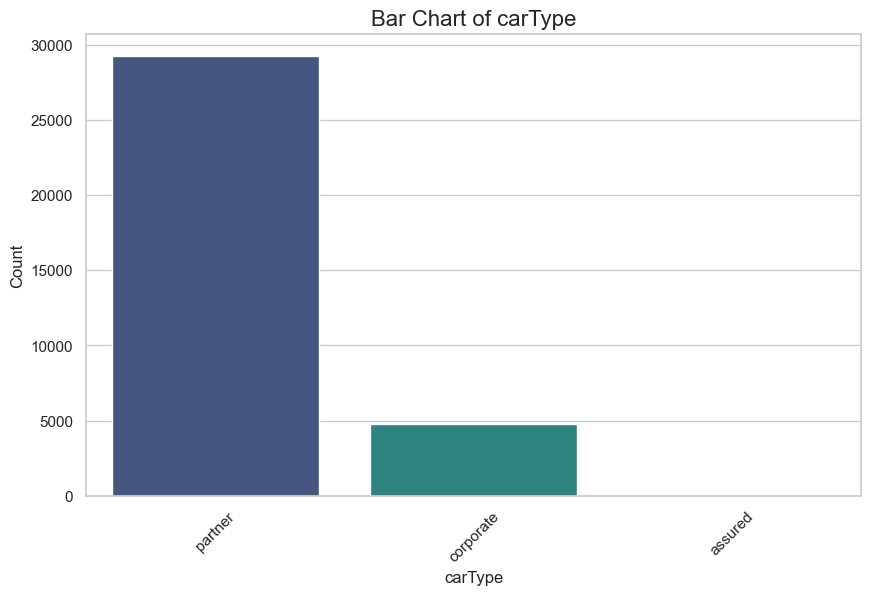

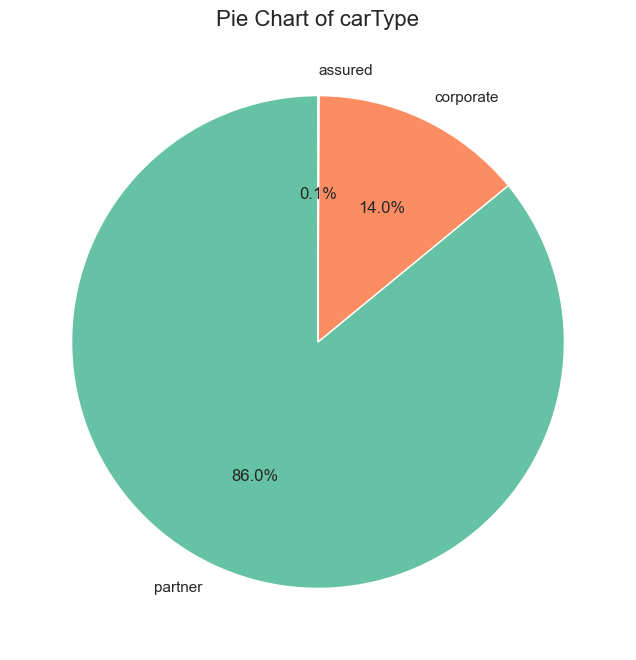

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


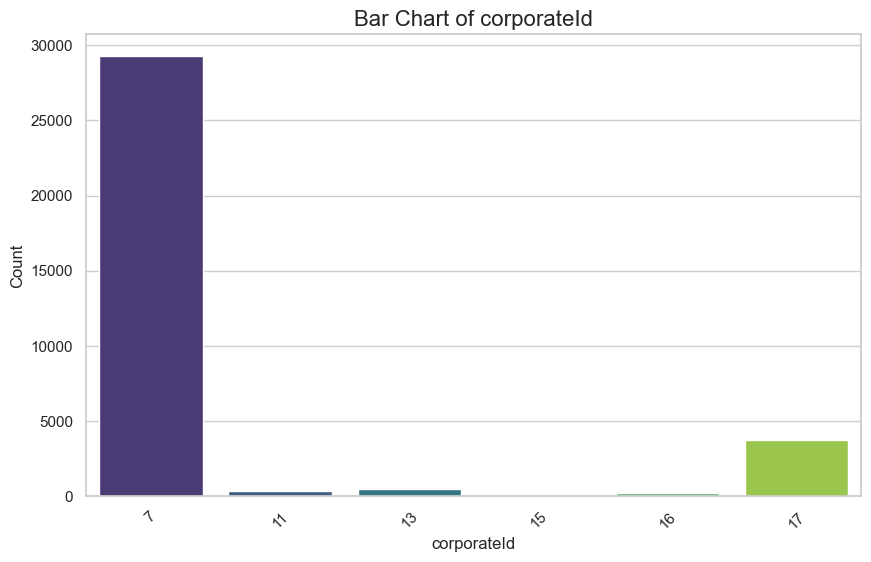

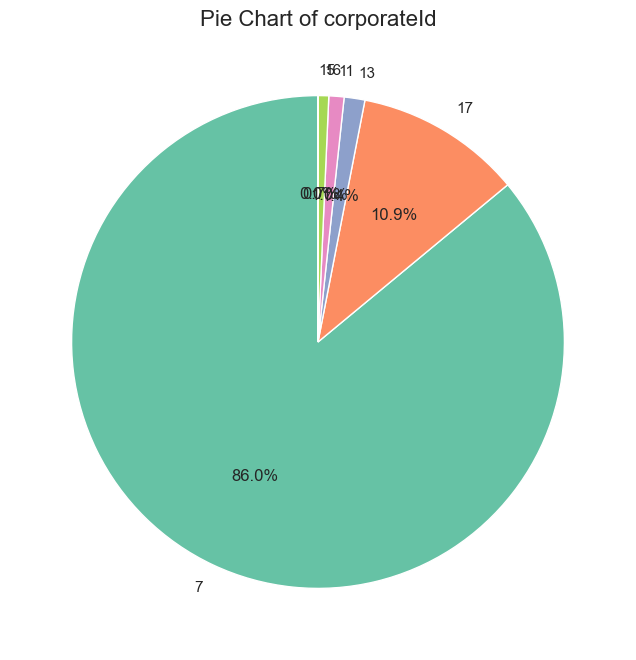

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


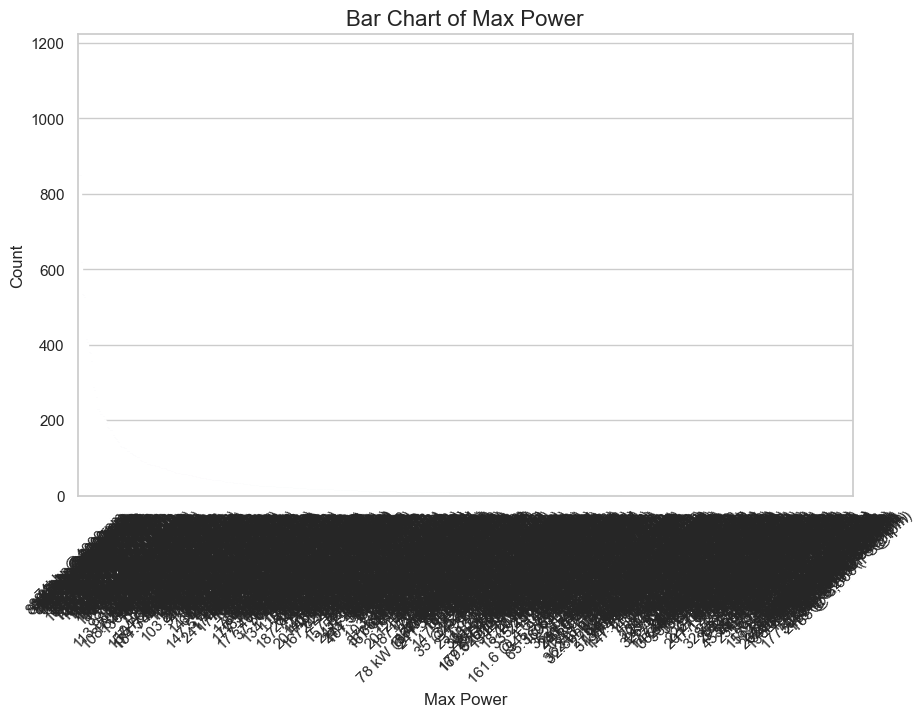

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


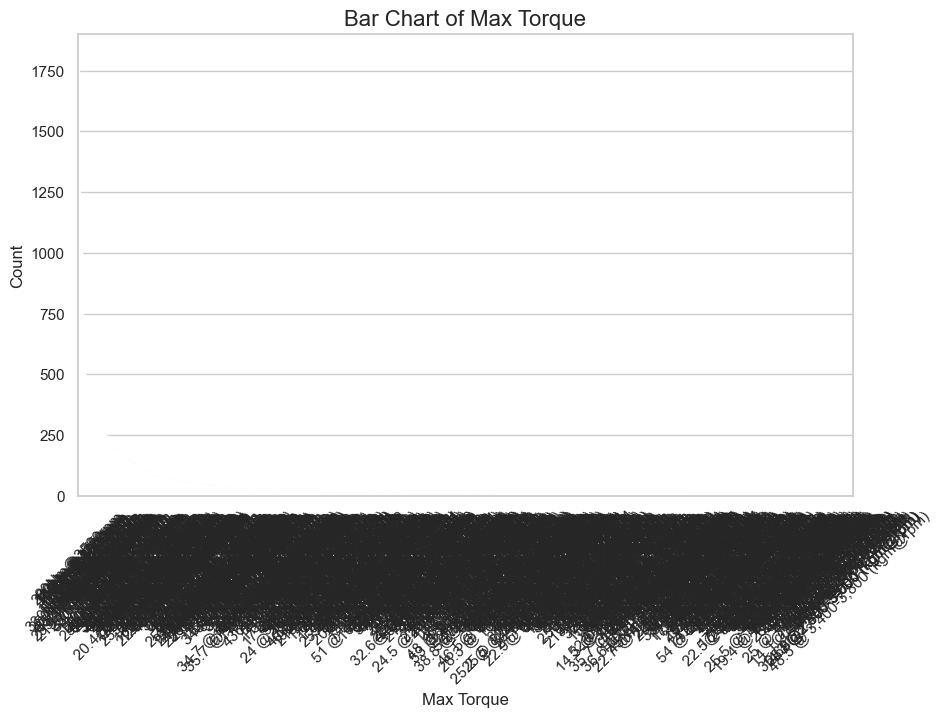

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


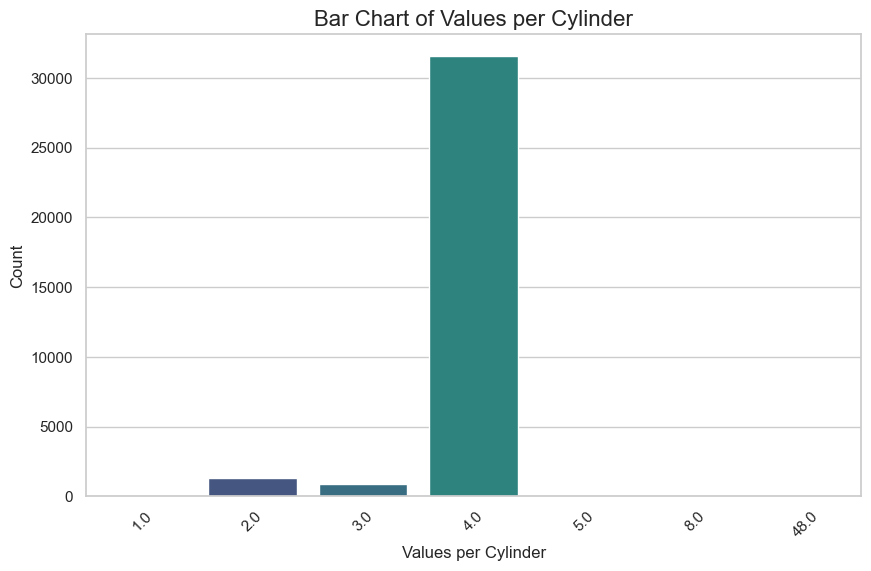

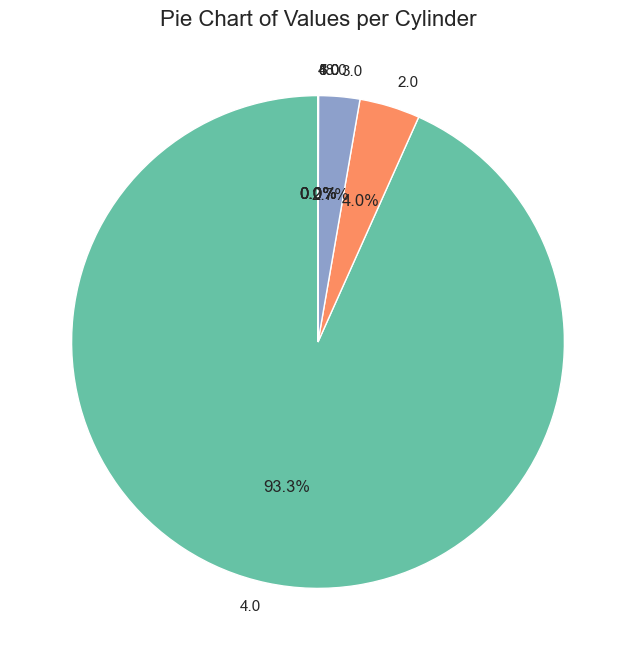

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


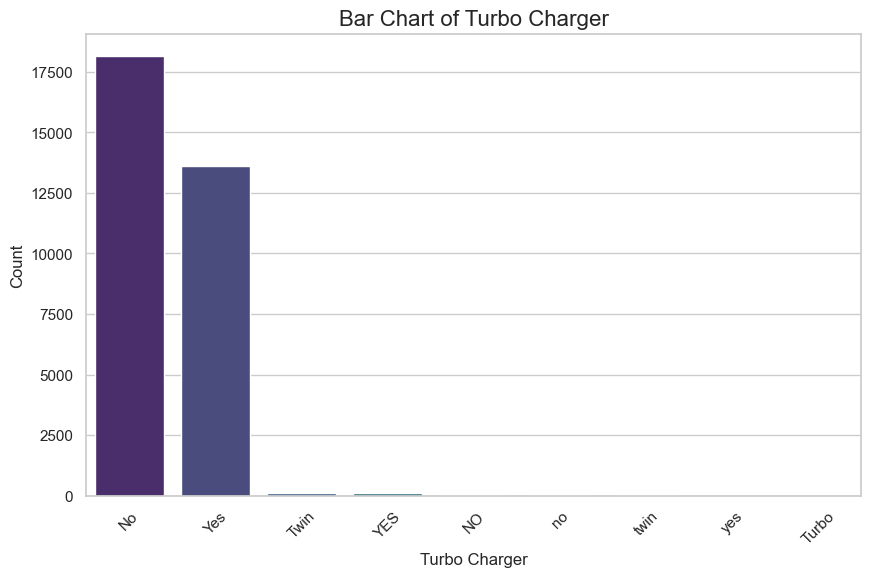

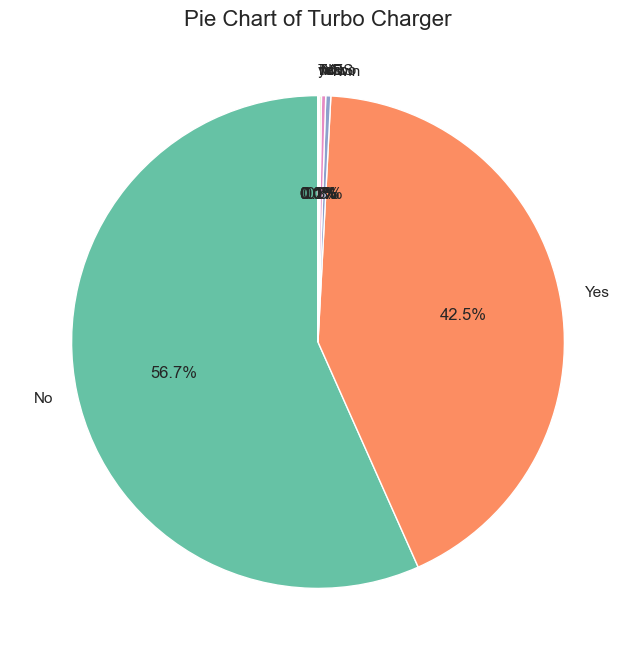

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


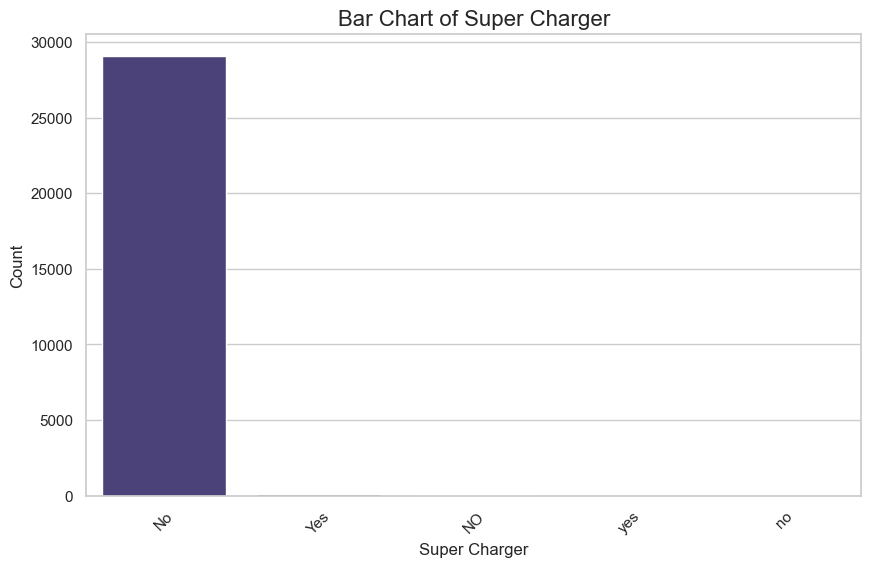

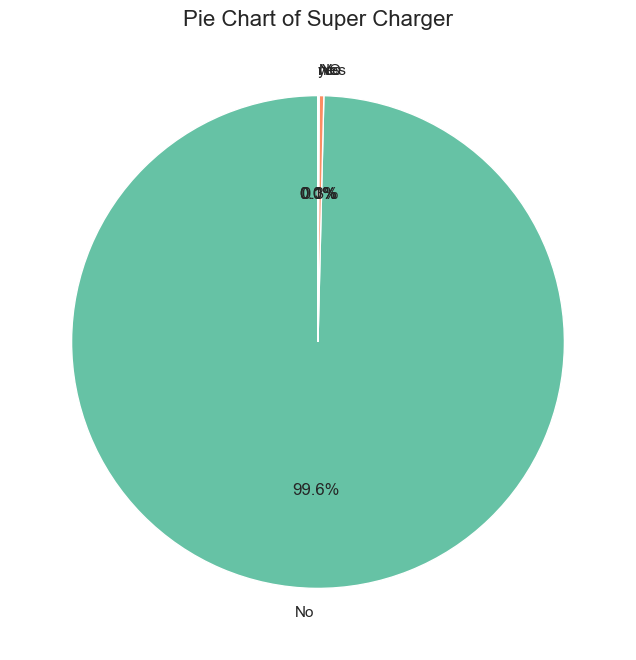

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


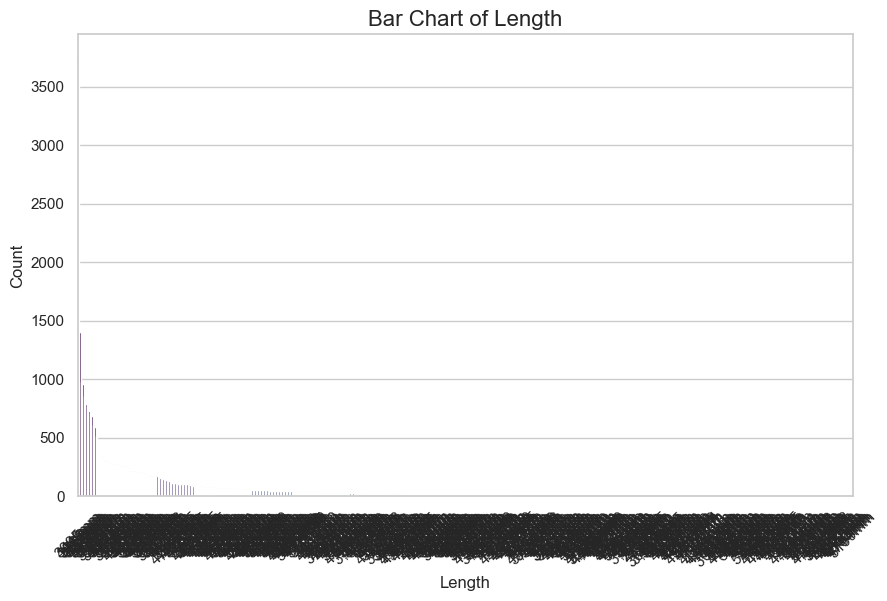

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


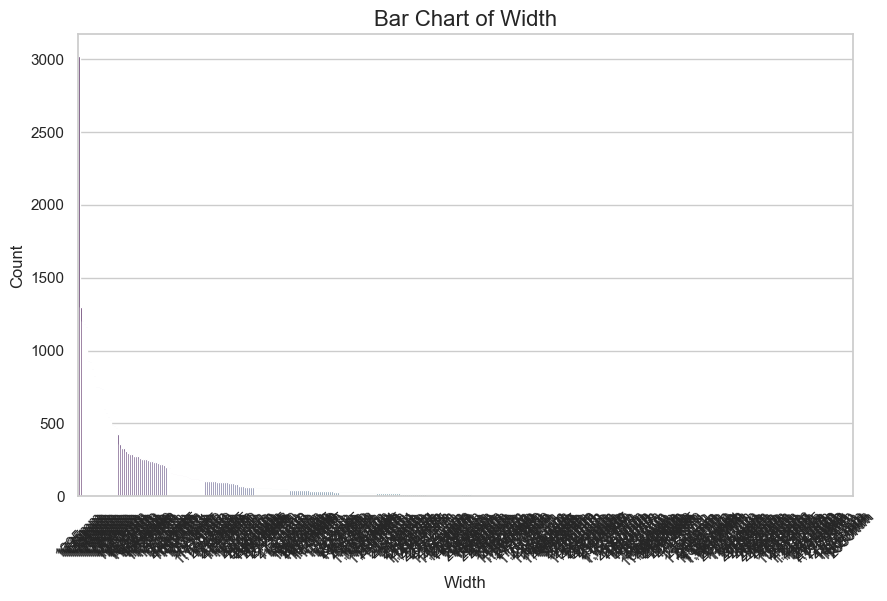

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


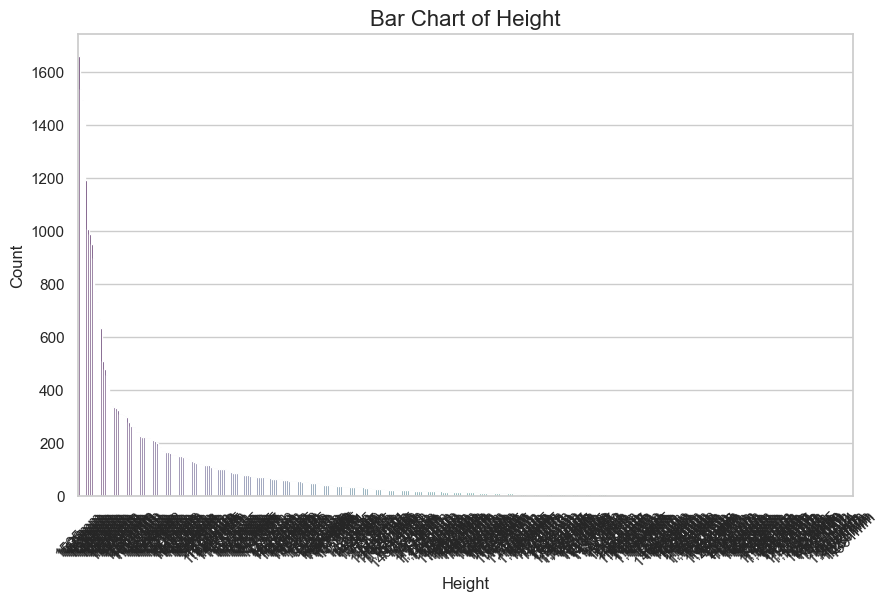

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


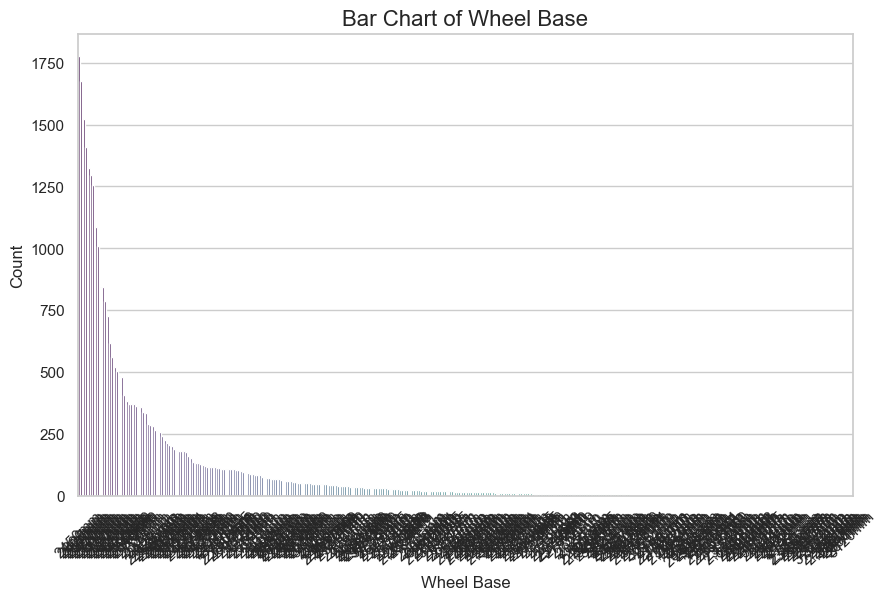

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


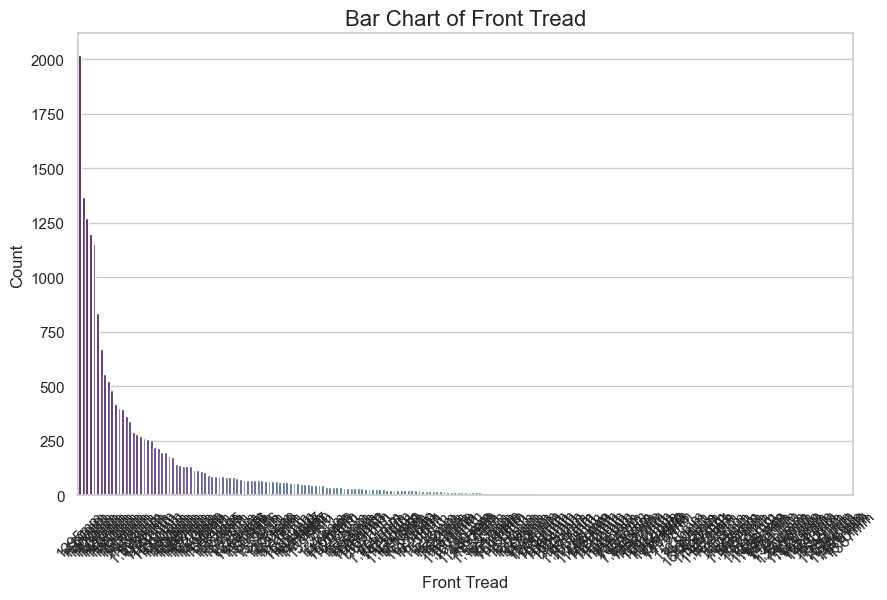

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


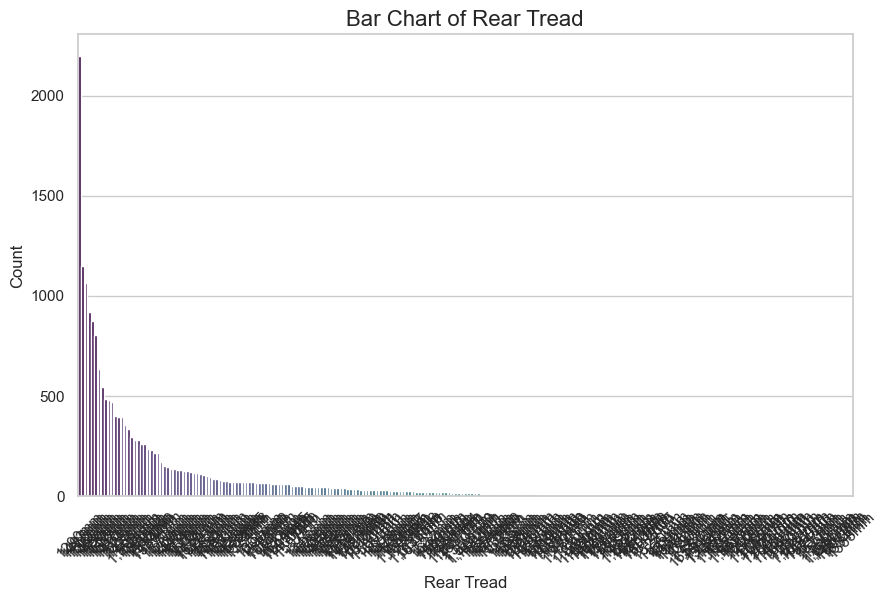

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


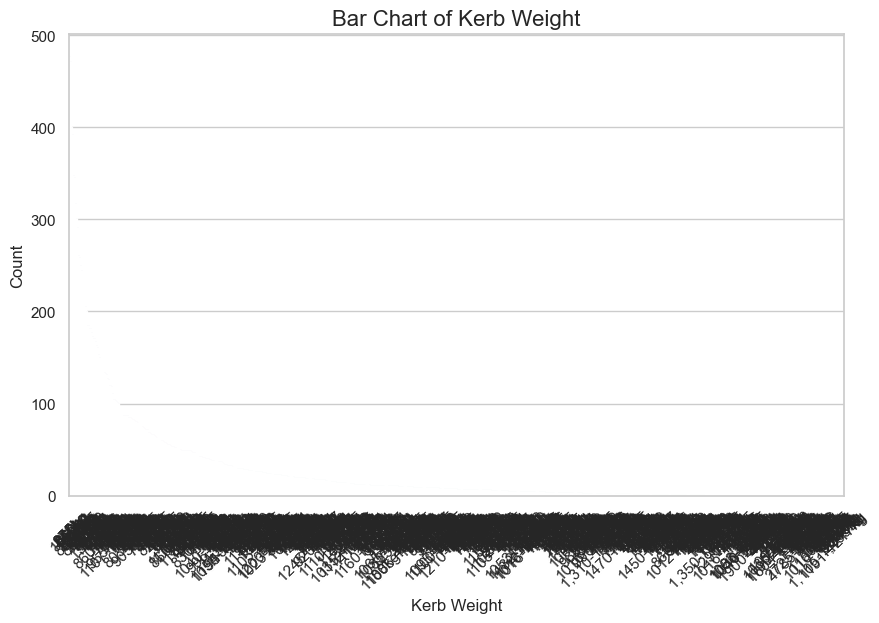

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


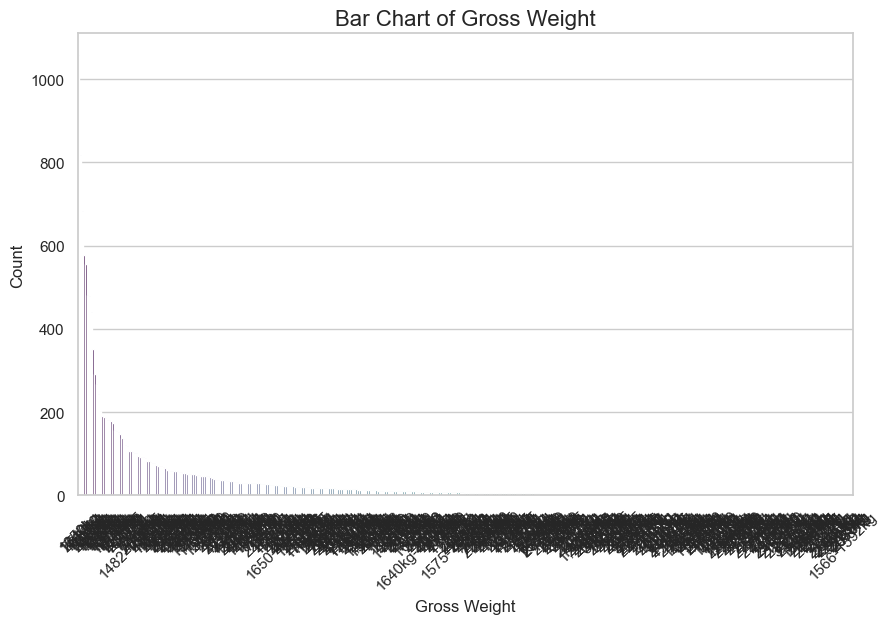

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


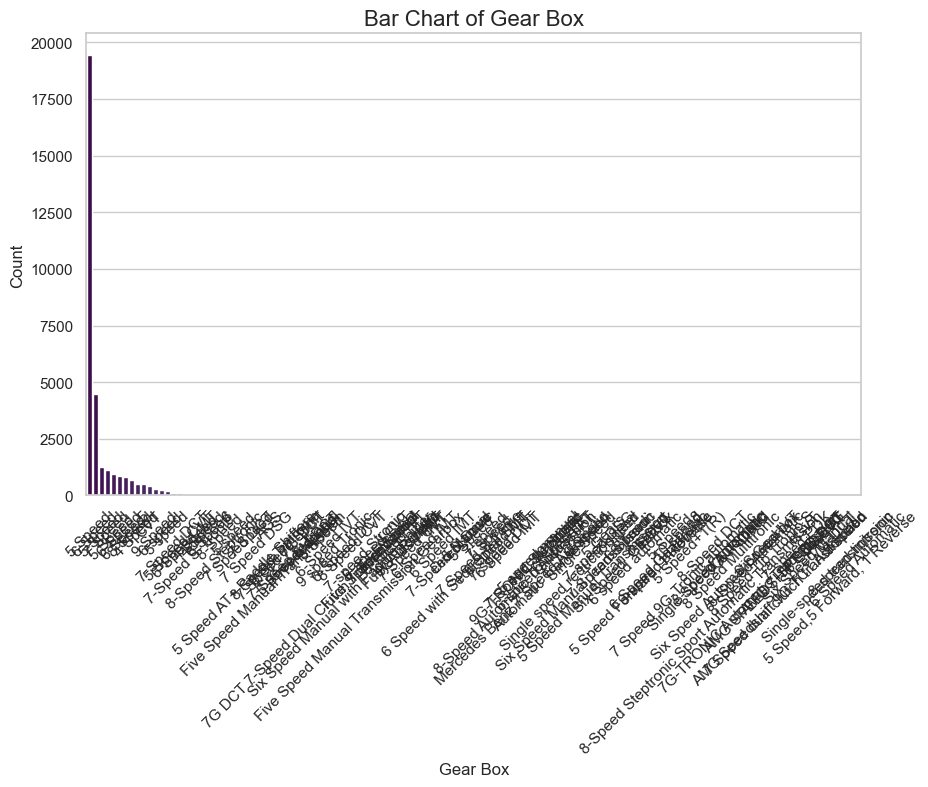

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


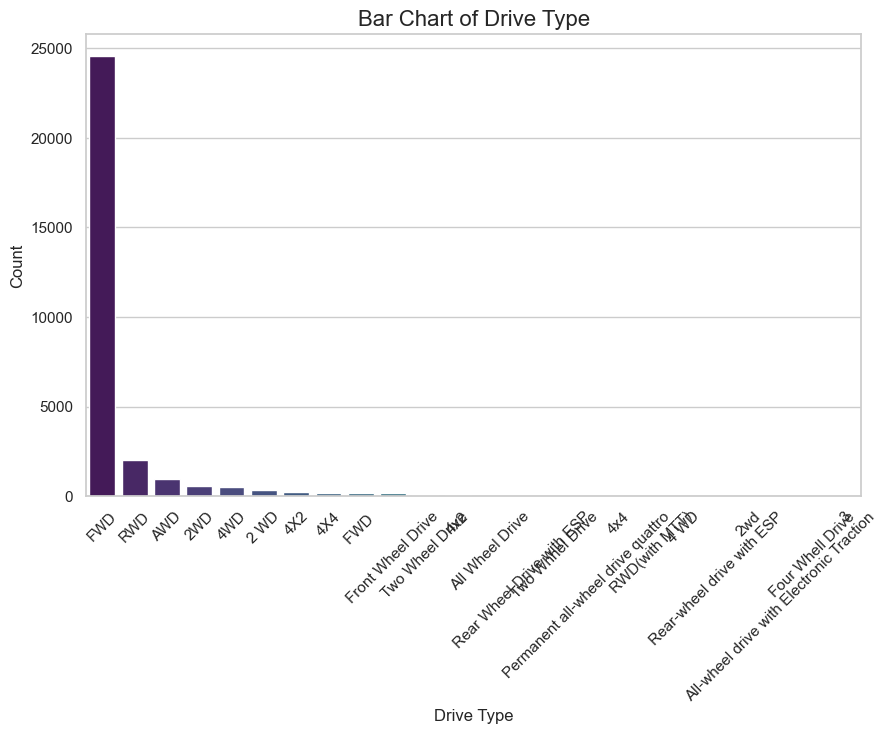

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


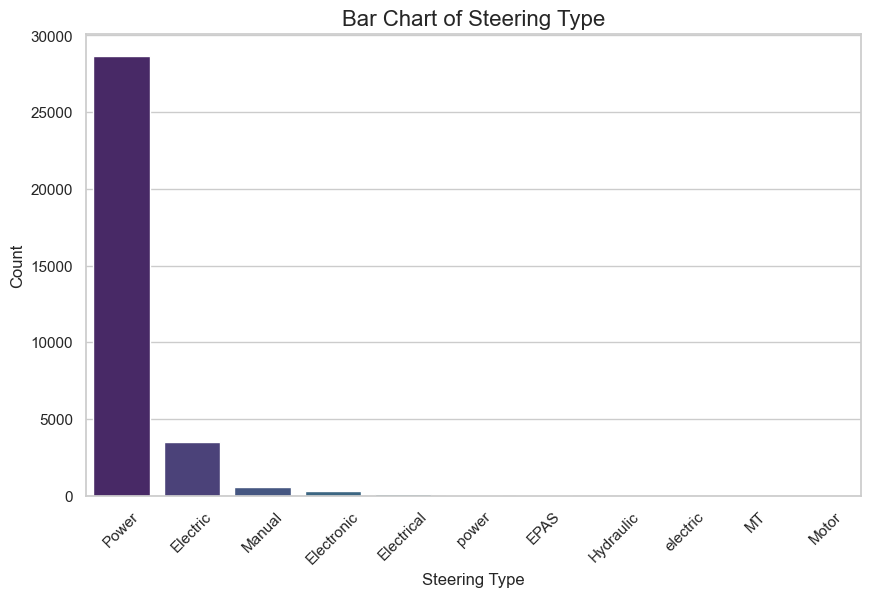

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


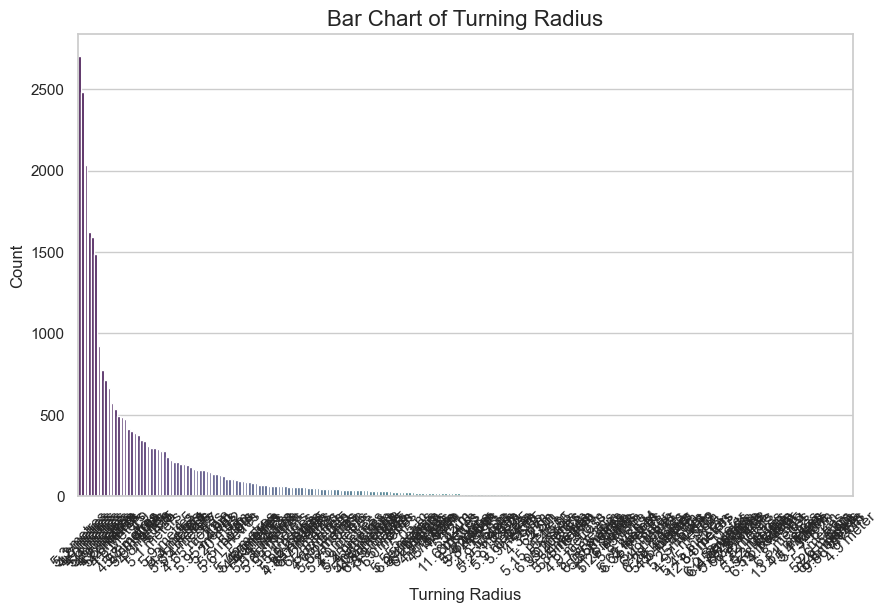

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


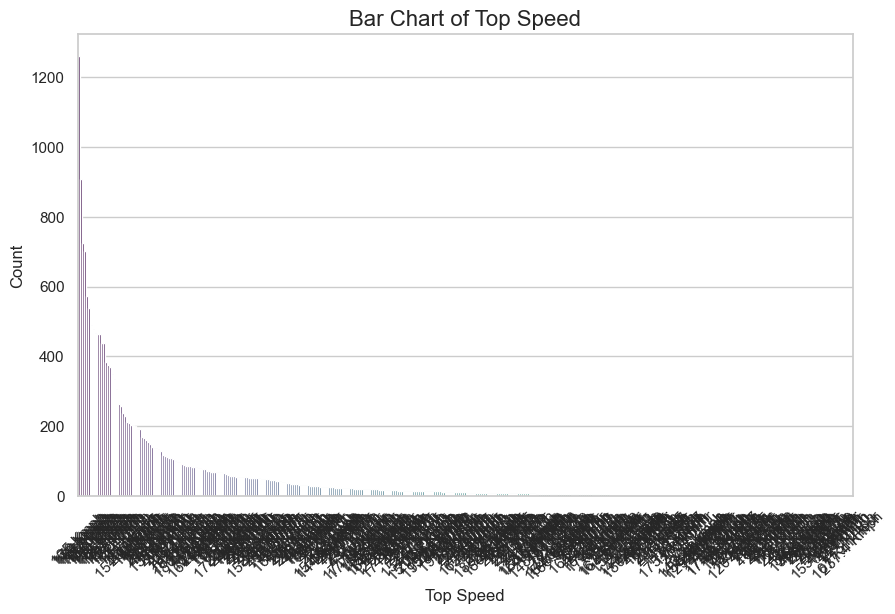

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


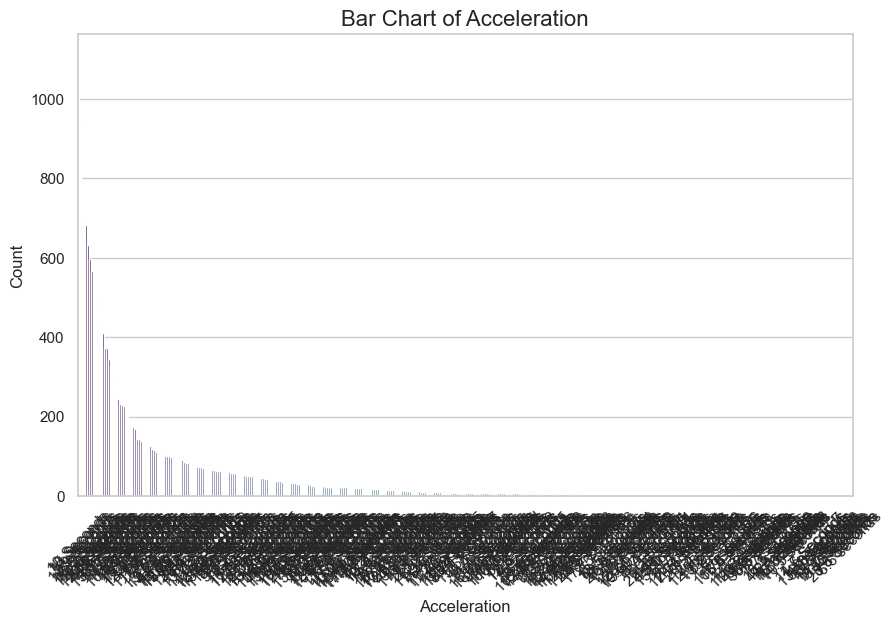

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


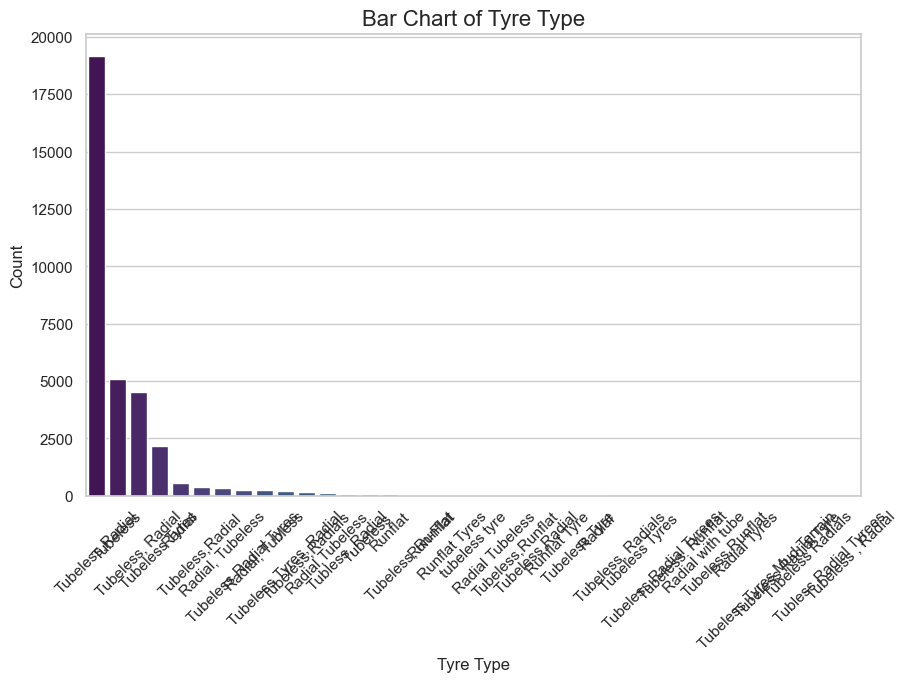

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


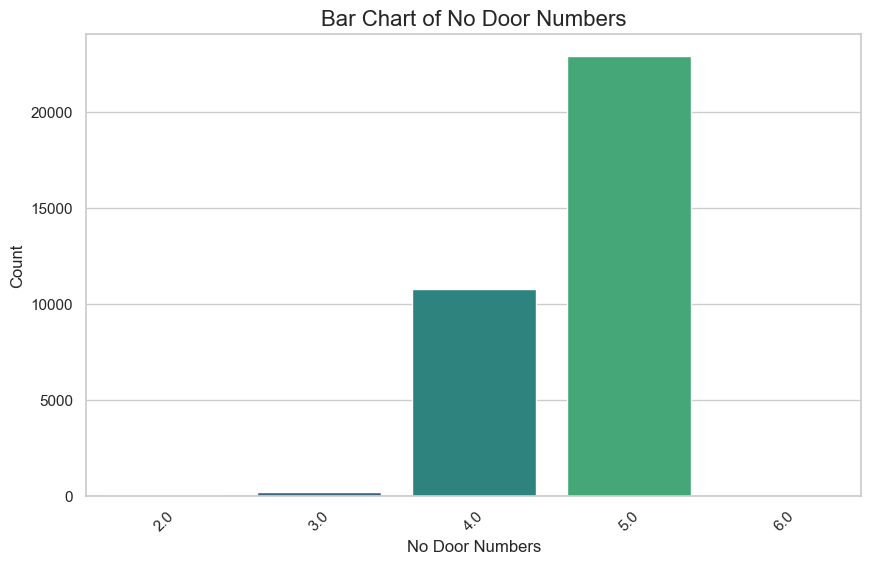

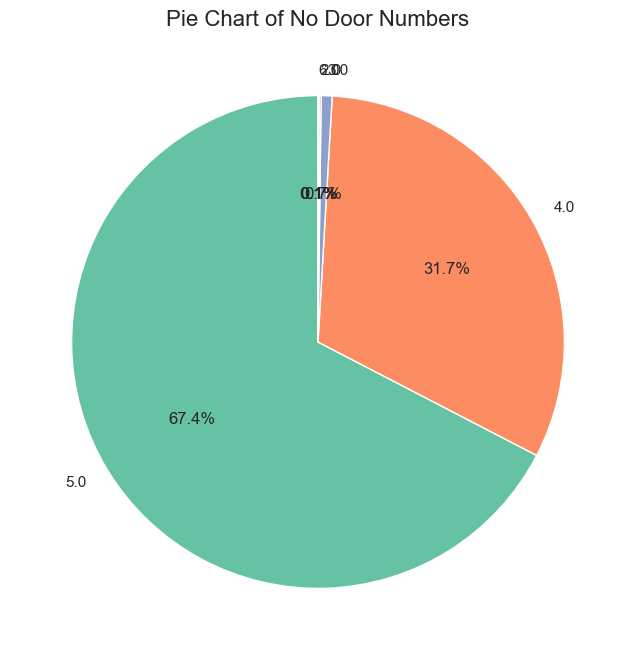

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


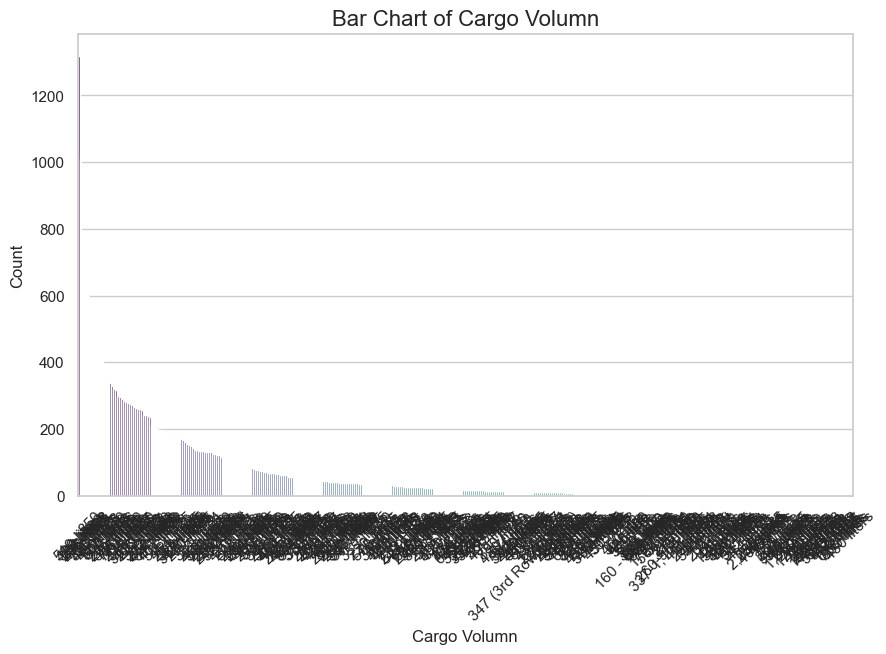

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


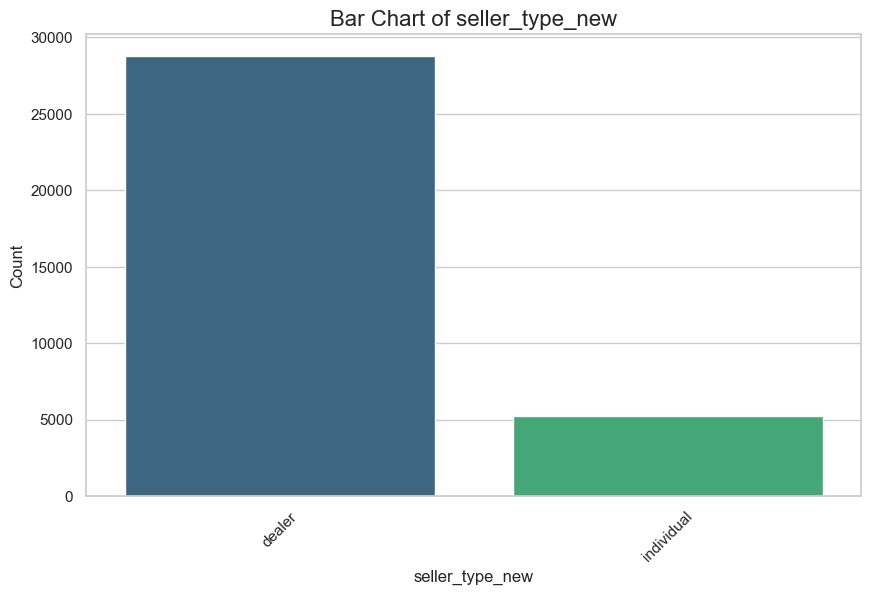

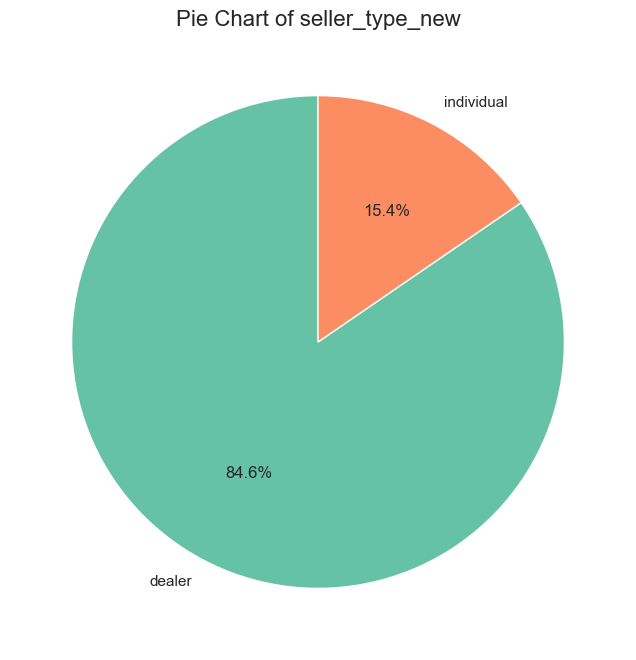

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


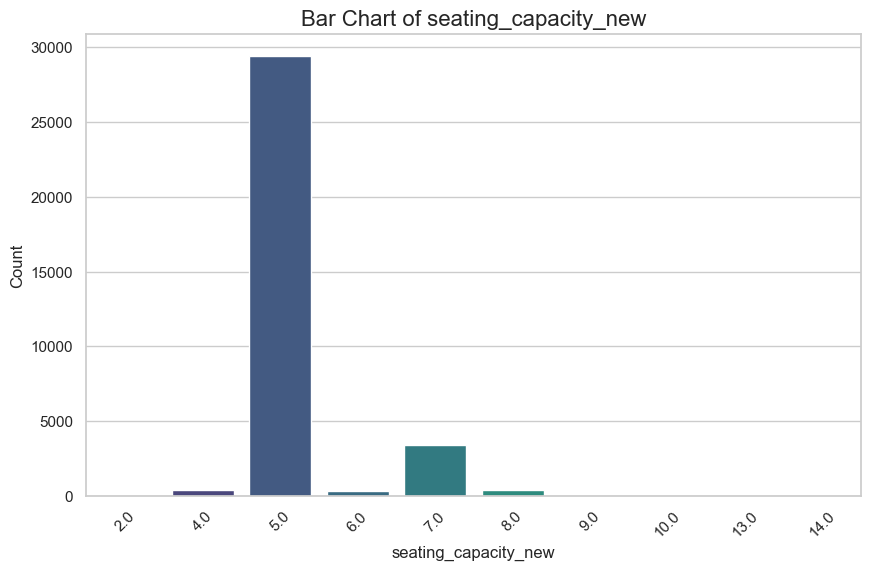

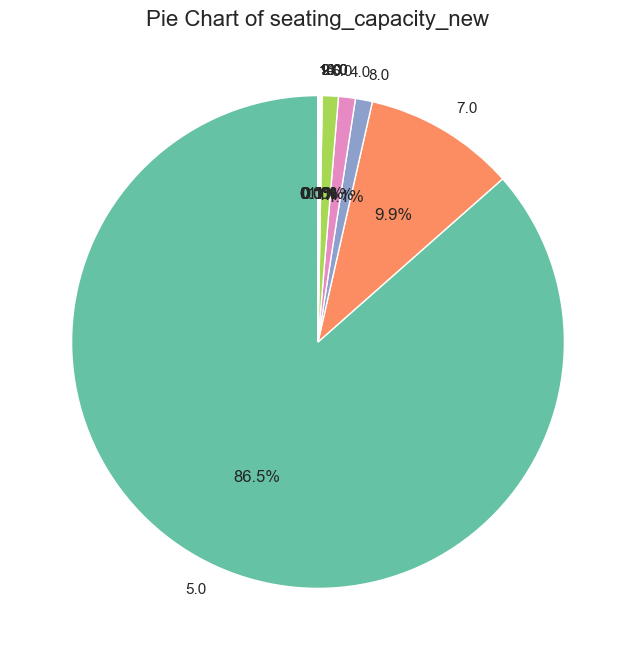

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


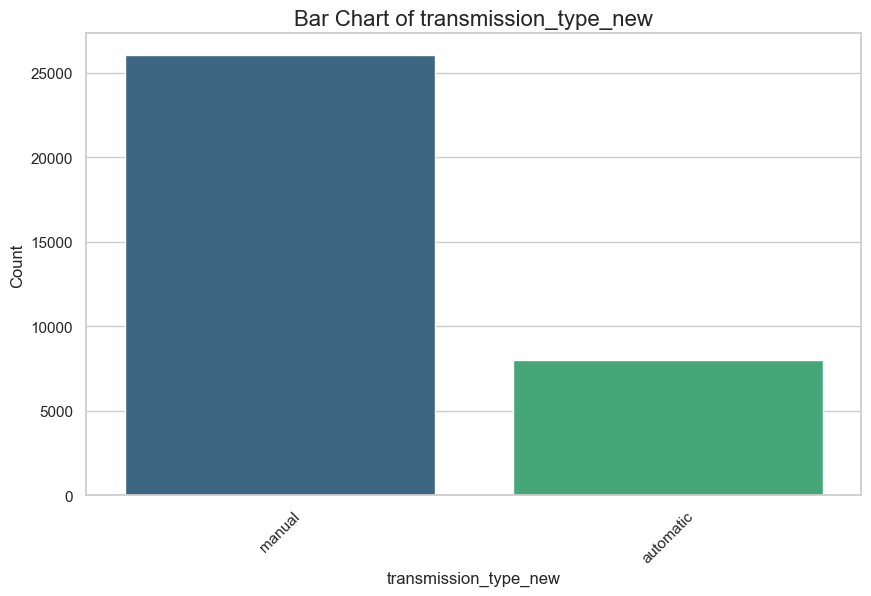

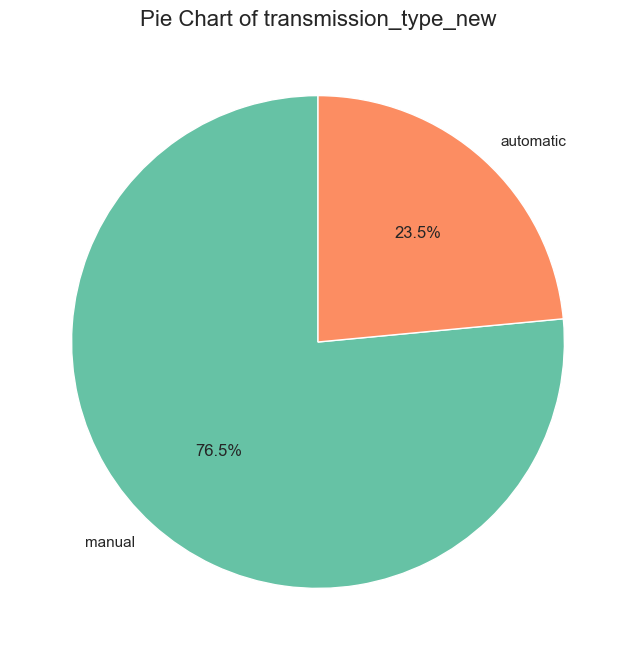

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


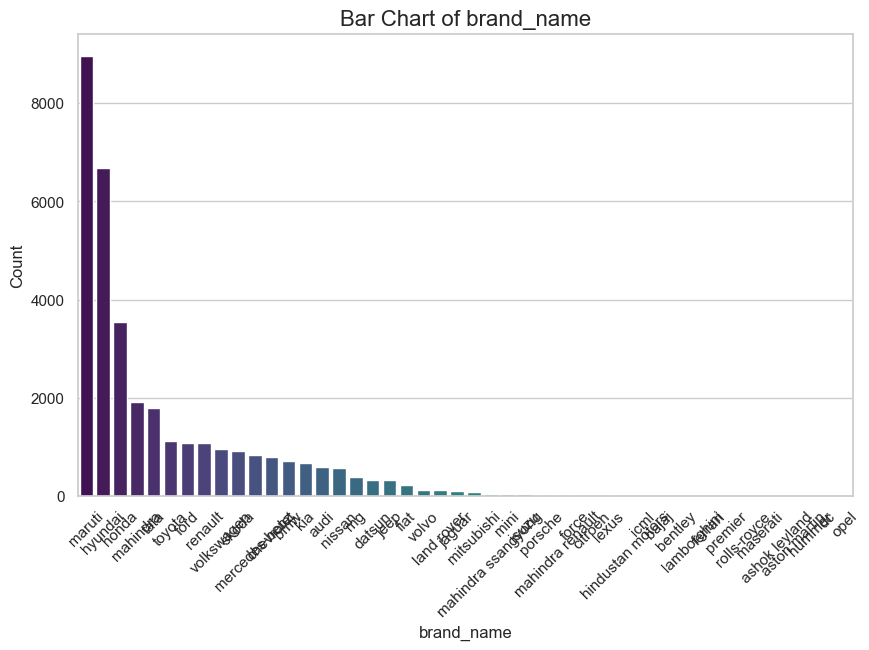

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


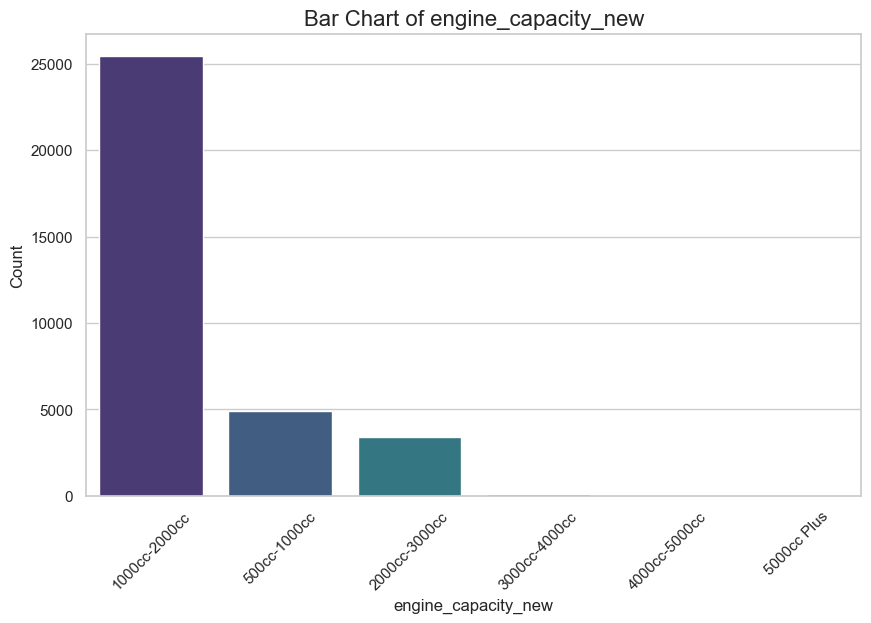

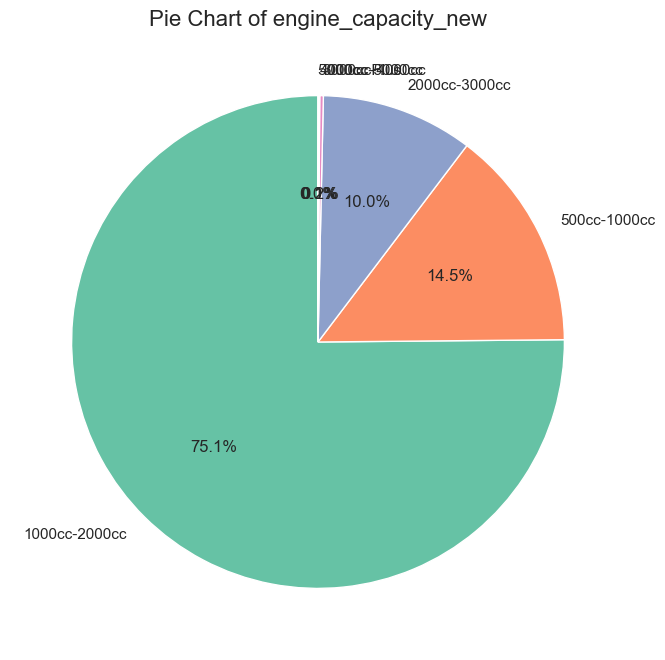

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


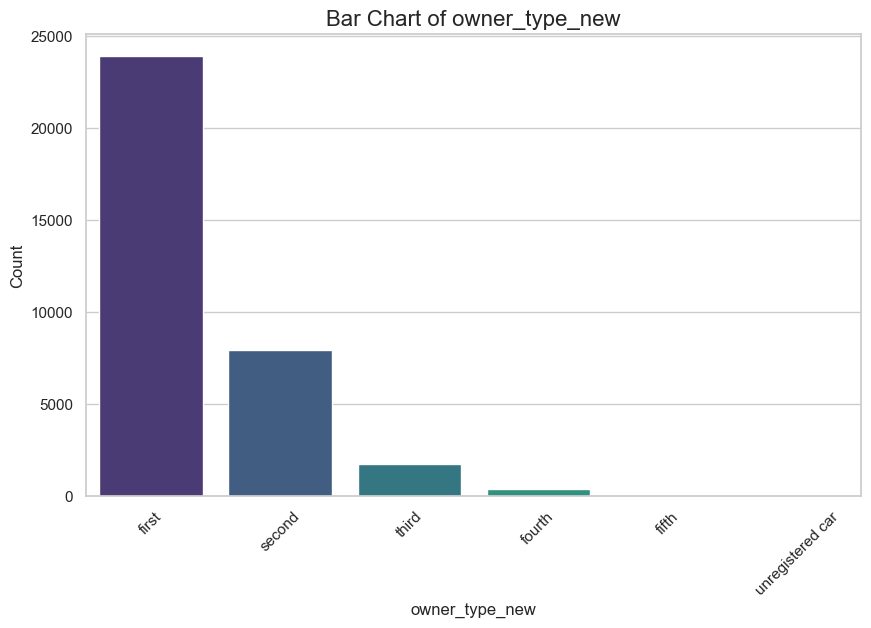

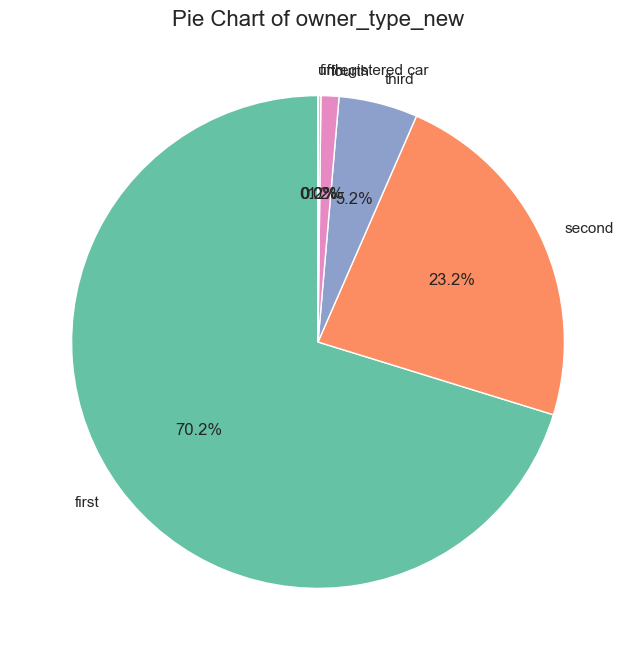

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


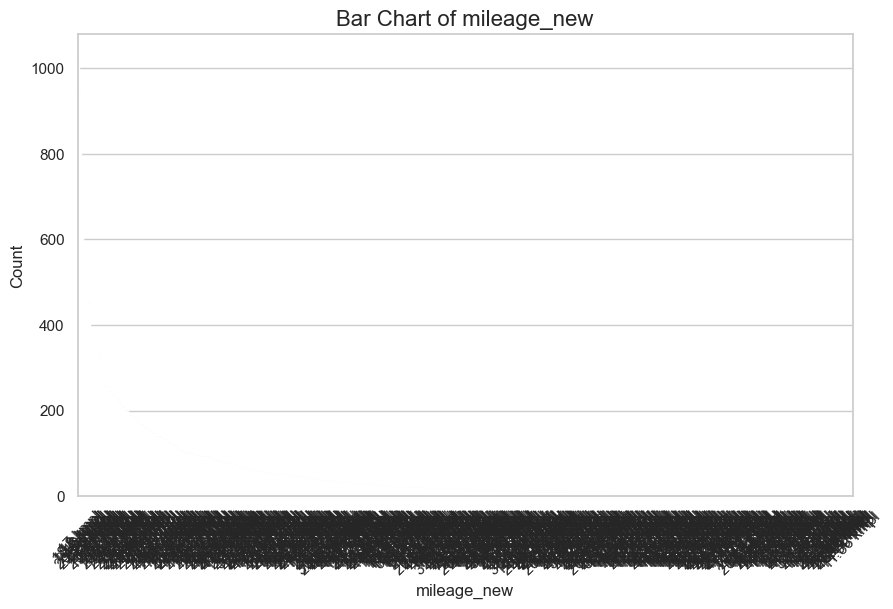

C:\Users\Kaz4n\AppData\Local\Temp\ipykernel_6296\4271175993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


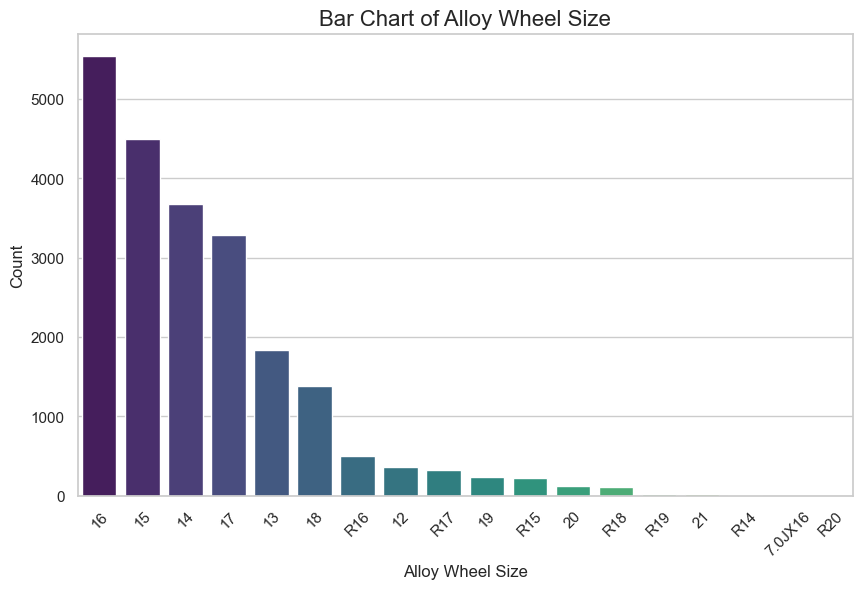

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to identify categorical columns
def identify_categorical_columns(df, max_unique_values=10):
    """
    Identify categorical columns based on:
    1. Columns with 'object' dtype.
    2. Numerical columns with a small number of unique values.
    """
    categorical_cols = []
    for col in df.columns:
        if df[col].dtype == 'object':  # Object columns are typically categorical
            categorical_cols.append(col)
        elif df[col].nunique() <= max_unique_values:  # Low-cardinality numerical columns
            categorical_cols.append(col)
    return categorical_cols

# Identify categorical columns
categorical_columns = identify_categorical_columns(data)

# Set up the plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Loop through each categorical column and create visualizations
for column in categorical_columns:
    # Count the occurrences of each category
    category_counts = data[column].value_counts()

    # Bar Chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
    plt.title(f"Bar Chart of {column}", fontsize=16)
    plt.xlabel(column, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.show()

    # Pie Chart
    if len(category_counts) <= 10:  # Only create pie charts for columns with <= 10 categories
        plt.figure(figsize=(8, 8))
        plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
        plt.title(f"Pie Chart of {column}", fontsize=16)
        plt.show()
        

# Theres a lot of catagorical features that have many unique values in them which cannot be grouped into common groups, so trying to encode them will rather make the model catch unwanted noise and may lead our model to detect unwanted detections, so no need for some of them

# Data Preprocessing:

In [28]:

# Step 1: Fix formatting issues
# Price (`pu`)
data['pu'] = data['pu'].str.replace(',', '').astype(float)

# Max Power
data['Max Power'] = data['Max Power'].str.extract(r'(\d+\.?\d*)bhp').astype(float)

# Max Torque
data['Max Torque'] = data['Max Torque'].str.extract(r'(\d+\.?\d*)Nm').astype(float)

# Top Speed
data['Top Speed'] = data['Top Speed'].str.extract(r'(\d+\.?\d*)').astype(float)

# Acceleration
data['Acceleration'] = data['Acceleration'].str.extract(r'(\d+\.?\d*)').astype(float)

# Mileage (`mileage_new`)
data['mileage_new'] = data['mileage_new'].str.extract(r'(\d+\.?\d*)').astype(float)

data["car_age"] = 2025 - data["myear"]


In [29]:
# Turbo Charger and Super Charger
data['Turbo Charger'] = data['Turbo Charger'].str.lower().map({'yes': 1, 'no': 0})
data['Super Charger'] = data['Super Charger'].str.lower().map({'yes': 1, 'no': 0})

# One-hot encode 'carType' and drop the original column
if "ft" in data.columns:
    data = pd.get_dummies(data, columns=["ft"], prefix="ft")


In [30]:
# Clean the Gear Number column
def clean_gear_number(gear):
    if pd.isna(gear):  # Handle missing values
        return np.nan
    gear = gear.strip().lower()  # Normalize case and remove extra spaces
    if 'cvt' in gear:  # Handle CVT as null
        return np.nan
    # Extract the numeric part using regex
    numeric_part = ''.join(filter(str.isdigit, gear))
    return numeric_part if numeric_part else np.nan  # Return NaN if no number is found

# Apply the cleaning function
data['Gear Box'] = data['Gear Box'].apply(clean_gear_number)

# Print the cleaned column
print(data["Gear Box"])

0        5
1        6
2        5
3        6
4        5
        ..
34028    7
34029    5
34030    5
34031    5
34032    5
Name: Gear Box, Length: 34033, dtype: object


In [31]:
# Enhanced loop to show unique values, their counts, null counts, null percentage, and categorize columns
numerical_cols = []
categorical_cols = []

for col in data.columns:
    unique_vals = data[col].unique()
    num_null = data[col].isnull().sum()
    pct_null = 100 * num_null / len(data)
    dtype = data[col].dtype

    print(f"Column: {col}")
    print(f"  Unique values: {unique_vals[:10]}{' ...' if len(unique_vals) > 10 else ''}")
    print(f"  Number of unique values: {len(unique_vals)}")
    print(f"  Value counts (top 5):")
    print(data[col].value_counts(dropna=False).head())
    print(f"  Null values: {num_null} ({pct_null:.2f}%)")
    print(f"  Dtype: {dtype}")

    if pd.api.types.is_numeric_dtype(data[col]):
        numerical_cols.append(col)
        print("  Category: Numerical")
    else:
        categorical_cols.append(col)
        print("  Category: Categorical")
    print("-" * 40)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print(f"Total numerical columns: {len(numerical_cols)}")
print(f"Total categorical columns: {len(categorical_cols)}")

Column: myear
  Unique values: [2016 2014 2020 2018 2017 2011 2019 2013 2015 2012] ...
  Number of unique values: 34
  Value counts (top 5):
myear
2017    3534
2018    3310
2014    3171
2015    3116
2016    3057
Name: count, dtype: int64
  Null values: 0 (0.00%)
  Dtype: int64
  Category: Numerical
----------------------------------------
Column: bt
  Unique values: ['MUV' 'SUV' 'Hatchback' 'Sedan' 'Minivans' 'Coupe' 'Luxury Vehicles'
 'Convertibles' 'Pickup Trucks' nan] ...
  Number of unique values: 12
  Value counts (top 5):
bt
Hatchback    13580
Sedan         9467
SUV           8831
MUV           1628
Minivans       350
Name: count, dtype: int64
  Null values: 18 (0.05%)
  Dtype: object
  Category: Categorical
----------------------------------------
Column: tt
  Unique values: ['Manual' 'Automatic']
  Number of unique values: 2
  Value counts (top 5):
tt
Manual       26034
Automatic     7999
Name: count, dtype: int64
  Null values: 0 (0.00%)
  Dtype: object
  Category: Categorical

In [32]:


# Define features to use

features = ["pu", "Max Power", "Max Torque", "Top Speed", "Acceleration", "mileage_new", "Turbo Charger",
             "Super Charger", "km_driven", 'car_age' , 'ft_CNG',
               'ft_Diesel', 'ft_Electric', 'ft_LPG', 'ft_Petrol', "Gear Box"]
X = data[features]
y = data['tt']
# Encode target variable (`tt`)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


Numerical Columns:
['pu', 'Max Power', 'Max Torque', 'Top Speed', 'Acceleration', 'mileage_new', 'Turbo Charger', 'Super Charger', 'km_driven', 'car_age']


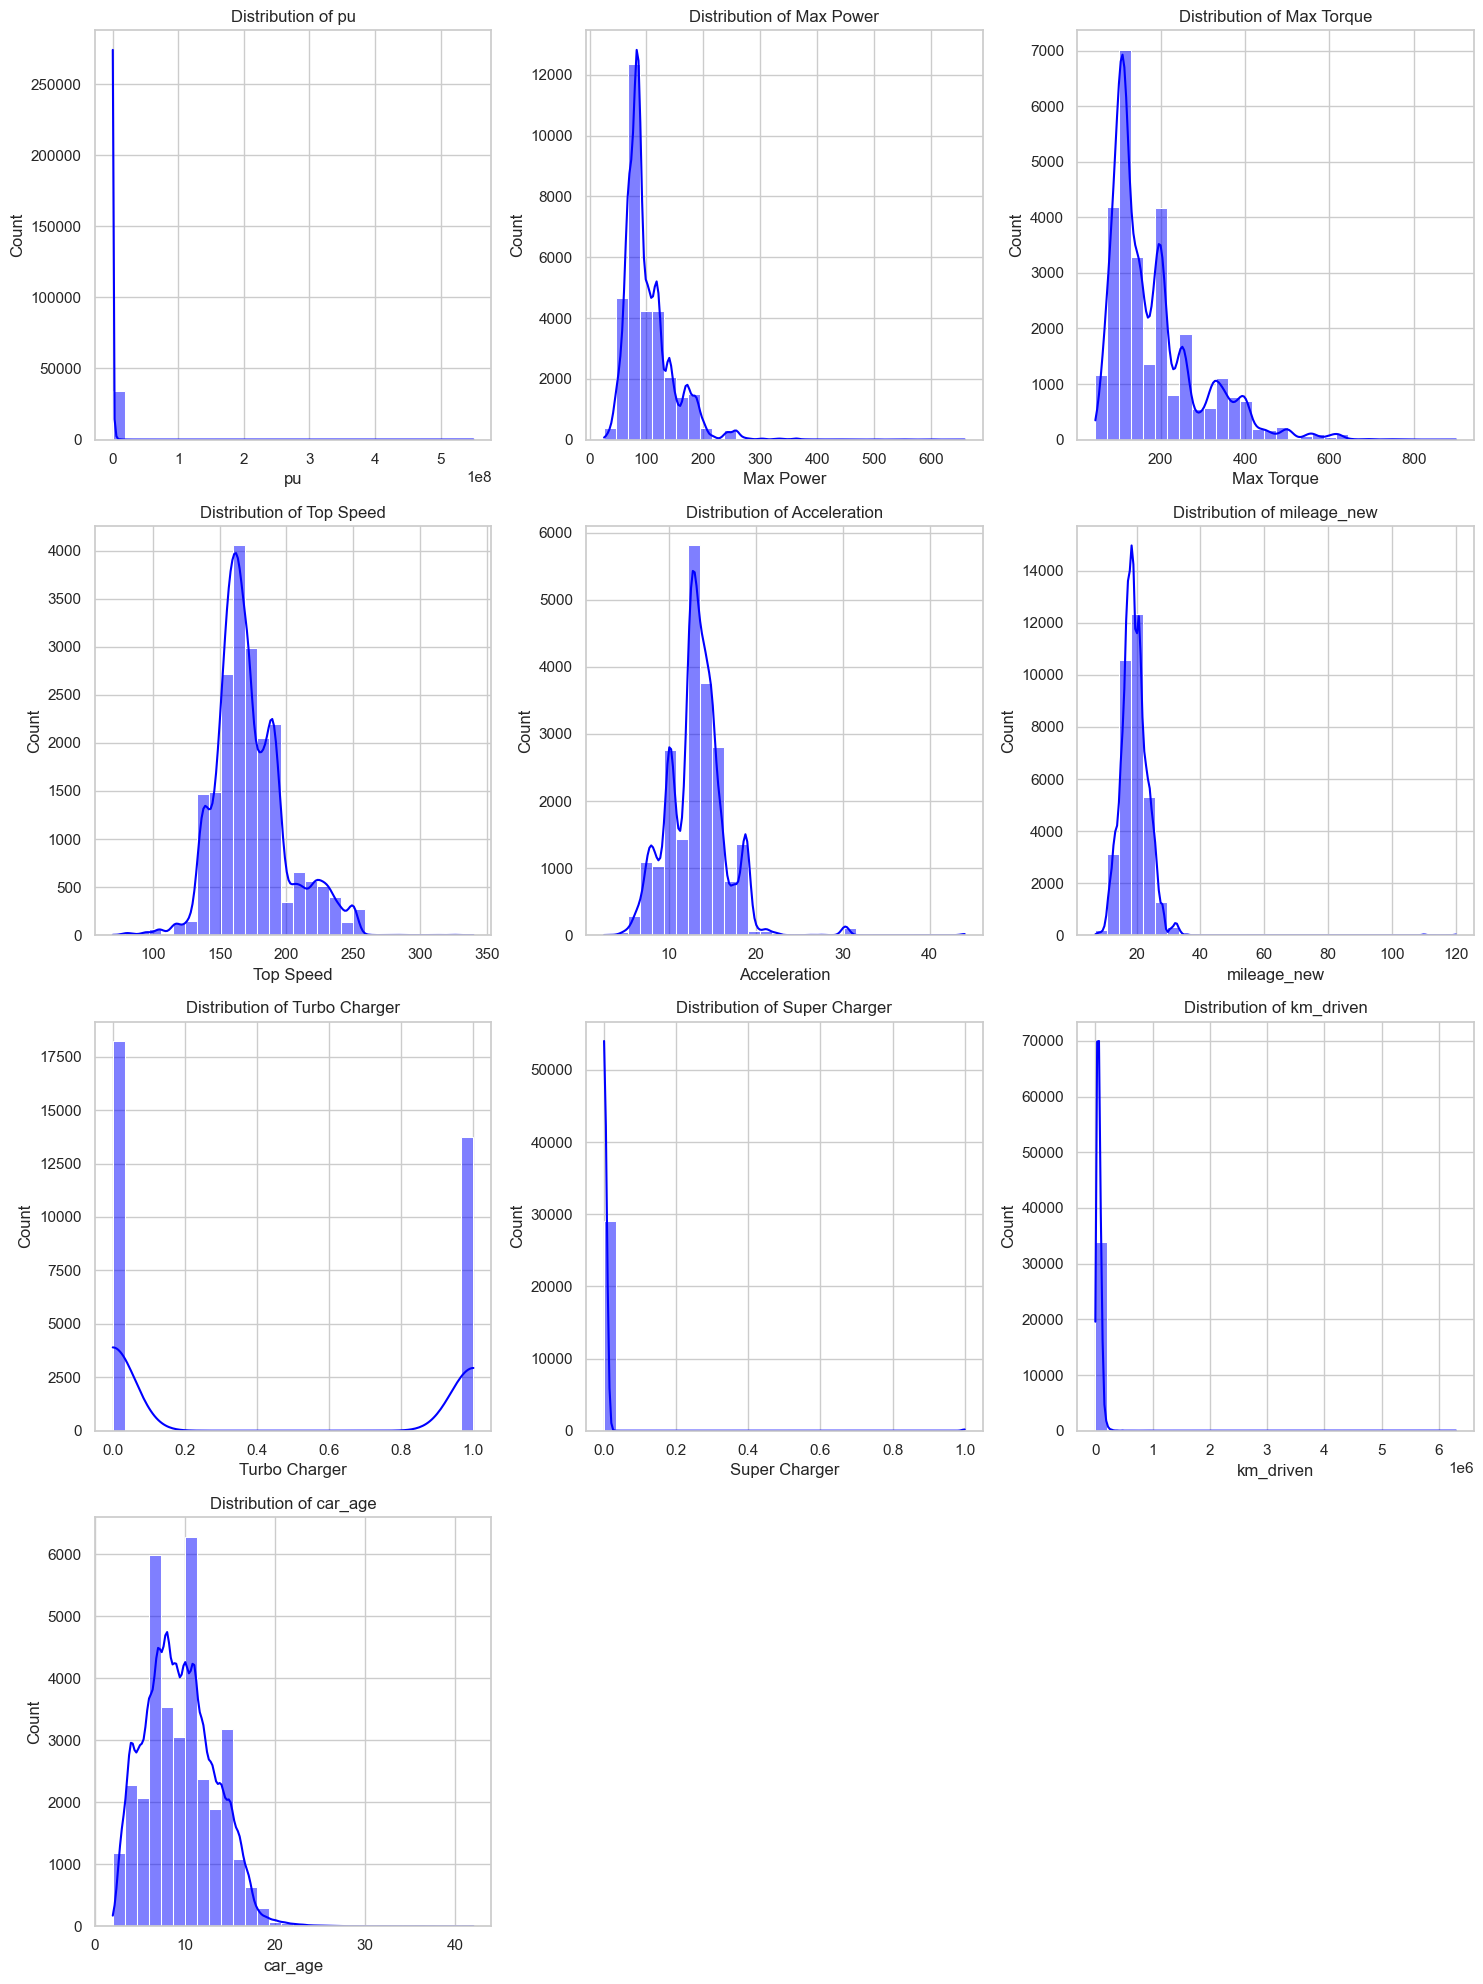

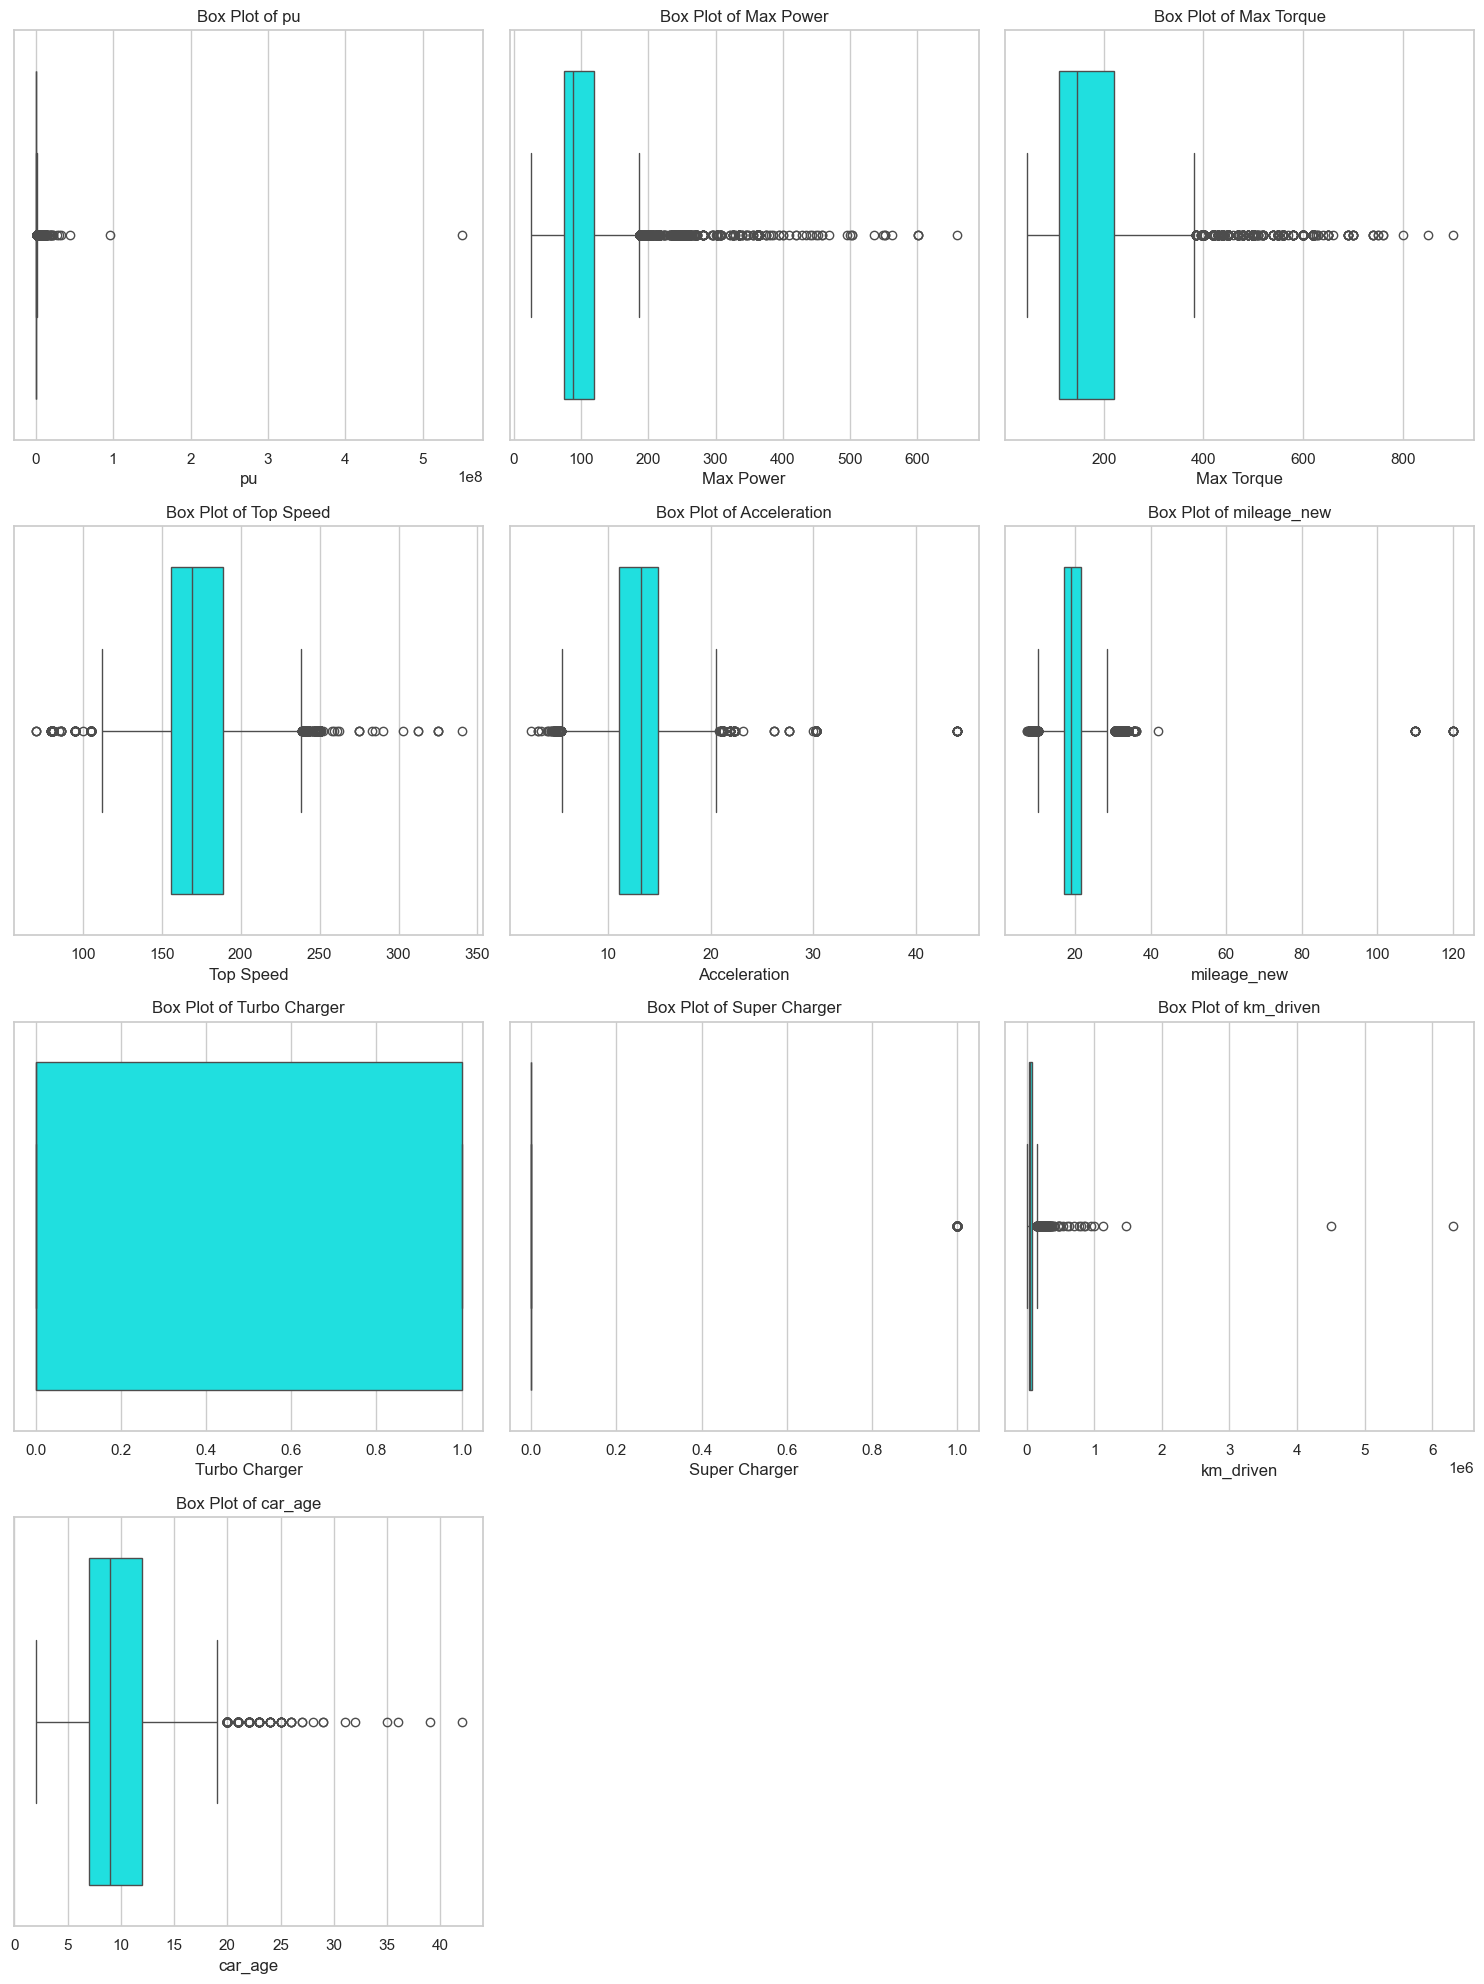

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (excluding boolean columns)
# Use select_dtypes to filter numeric columns (int, float) and exclude bool
numerical_data = X.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

# Print the numerical columns
print("Numerical Columns:")
print(numerical_data.columns.tolist())

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_data.columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# --- BOX PLOTS ---
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [34]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import StandardScaler


In [35]:
#getting the number of rows after splitting
X_train.shape[0], X_val.shape[0], y_train.shape[0], y_val.shape[0]  # Check the shapes of the splits

(27226, 6807, 27226, 6807)

In [36]:
# --- Apply Log Transform to `pu` ---
# Ensure no negative values (add 1 to handle zeros if needed)
X_train["pu"] = np.log1p(X_train["pu"])  # log(1 + x) for stability
X_val["pu"] = np.log1p(X_val["pu"])

In [37]:
# Calculate IQR bounds on TRAINING data

# Select only numeric columns for outlier handling
numerical_cols = X_train.select_dtypes(include=['float64', 'int64', 'int32', 'float32']).columns

# Calculate IQR bounds on TRAINING data (only for numeric columns)
Q1 = X_train[numerical_cols].quantile(0.15)
Q3 = X_train[numerical_cols].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip outliers in TRAINING and VALIDATION data (only for numeric columns)
X_train_clipped = X_train.copy()
X_val_clipped = X_val.copy()

X_train_clipped[numerical_cols] = X_train[numerical_cols].clip(lower_bound, upper_bound, axis=1)
X_val_clipped[numerical_cols] = X_val[numerical_cols].clip(lower_bound, upper_bound, axis=1)

# Ensure one-hot encoded features are preserved
non_numeric_cols = X_train.select_dtypes(exclude=['float64', 'int64', 'int32', 'float32']).columns
X_train_clipped[non_numeric_cols] = X_train[non_numeric_cols]
X_val_clipped[non_numeric_cols] = X_val[non_numeric_cols]

# Now X_train_clipped and X_val_clipped include both clipped numeric features and one-hot encoded features

Numerical Columns:
['pu', 'Max Power', 'Max Torque', 'Top Speed', 'Acceleration', 'mileage_new', 'Turbo Charger', 'Super Charger', 'km_driven', 'car_age']


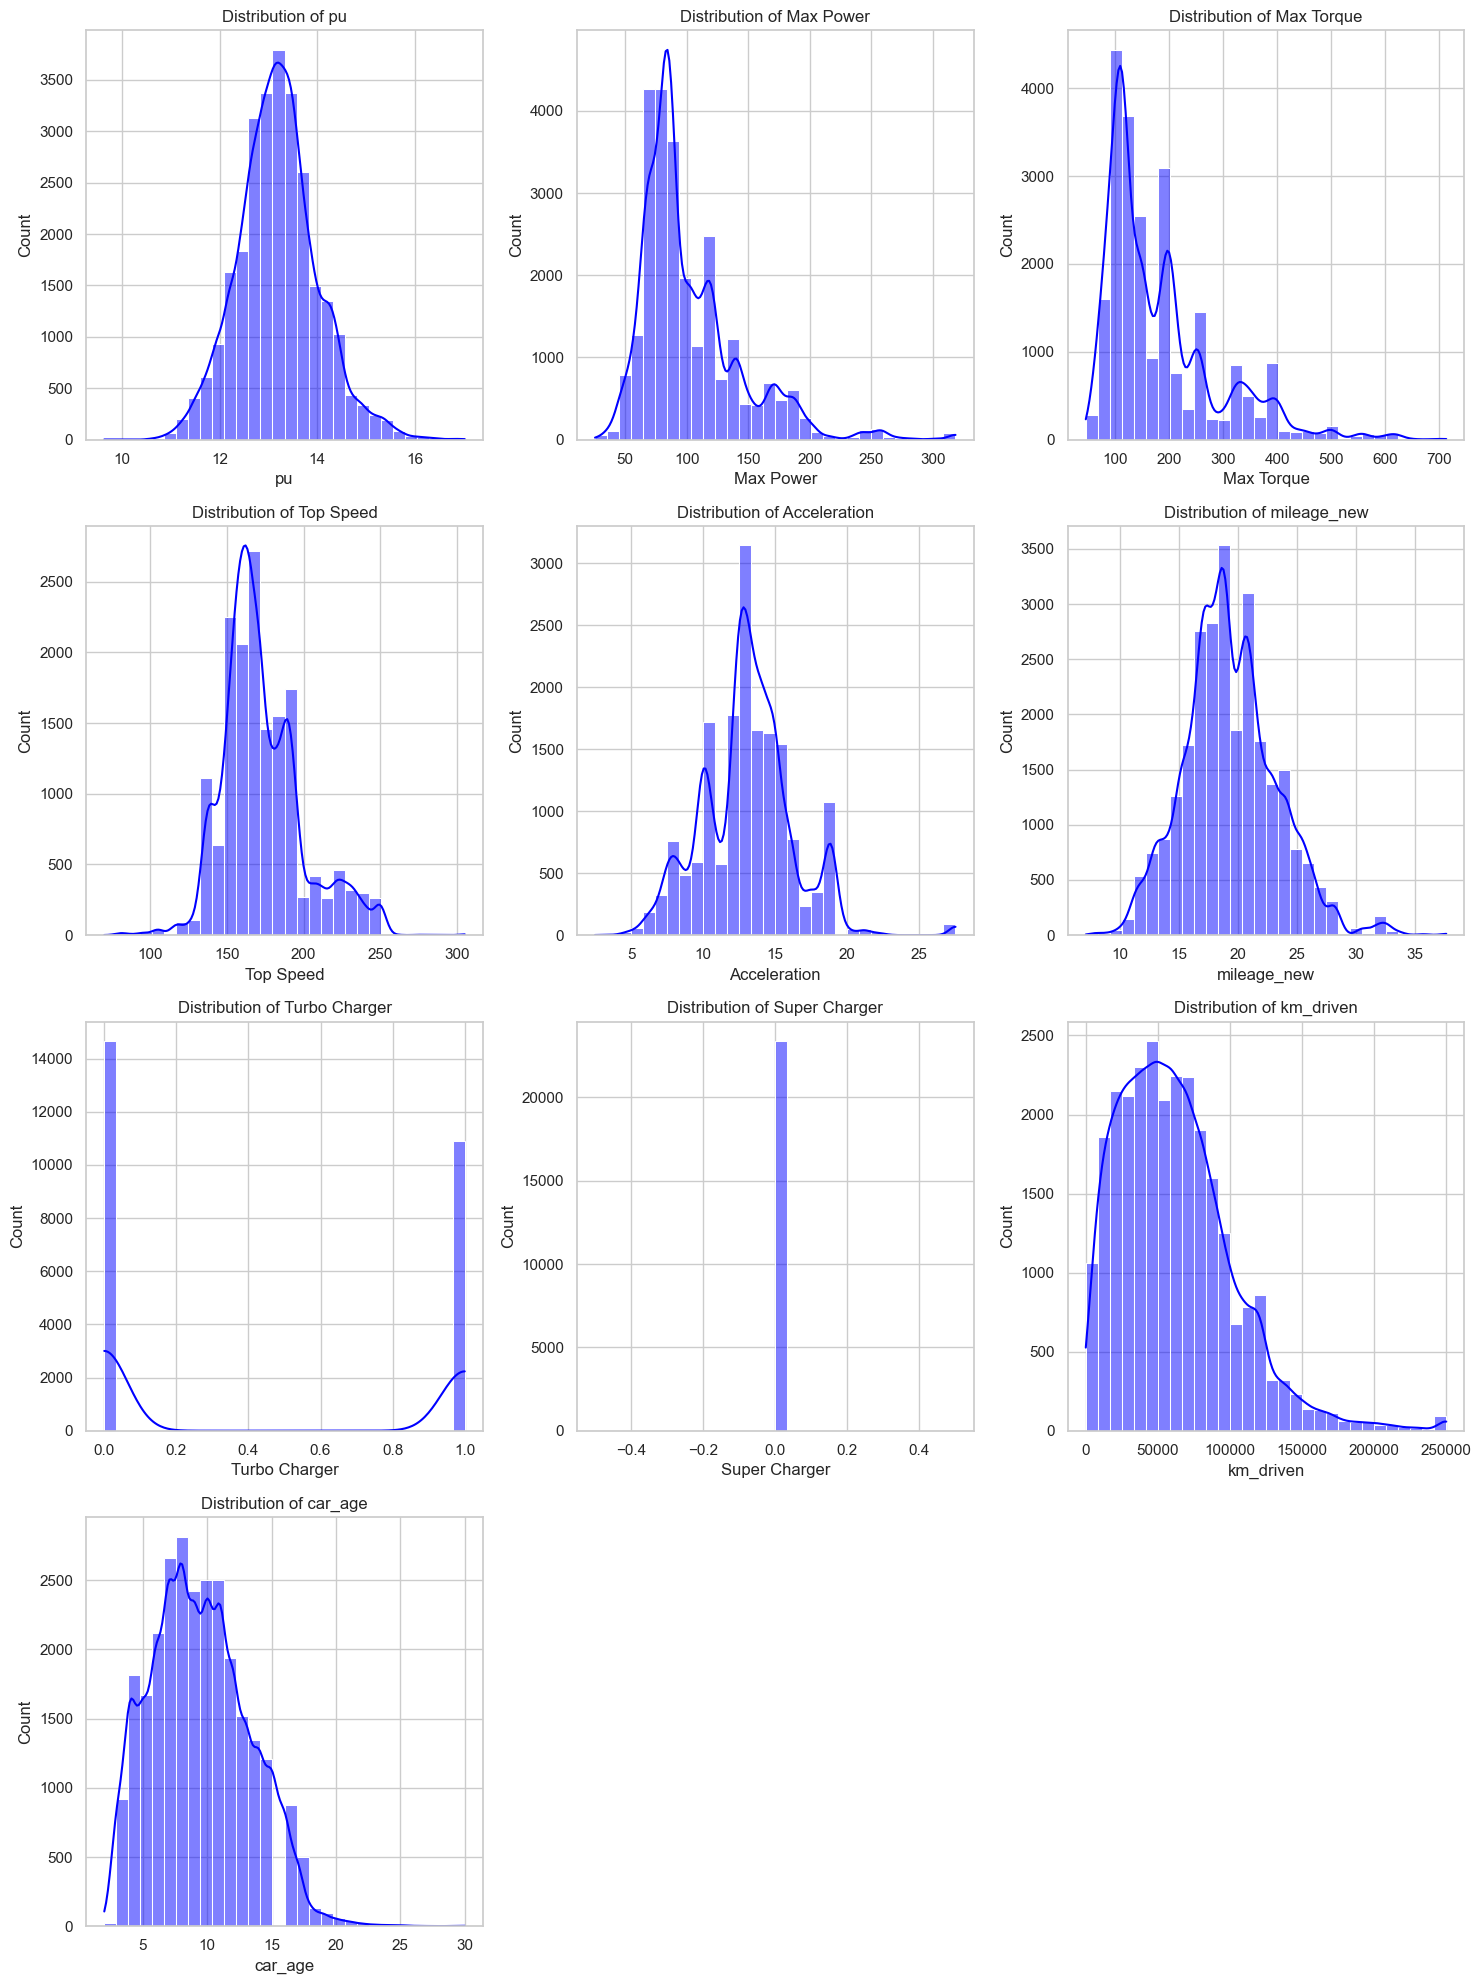

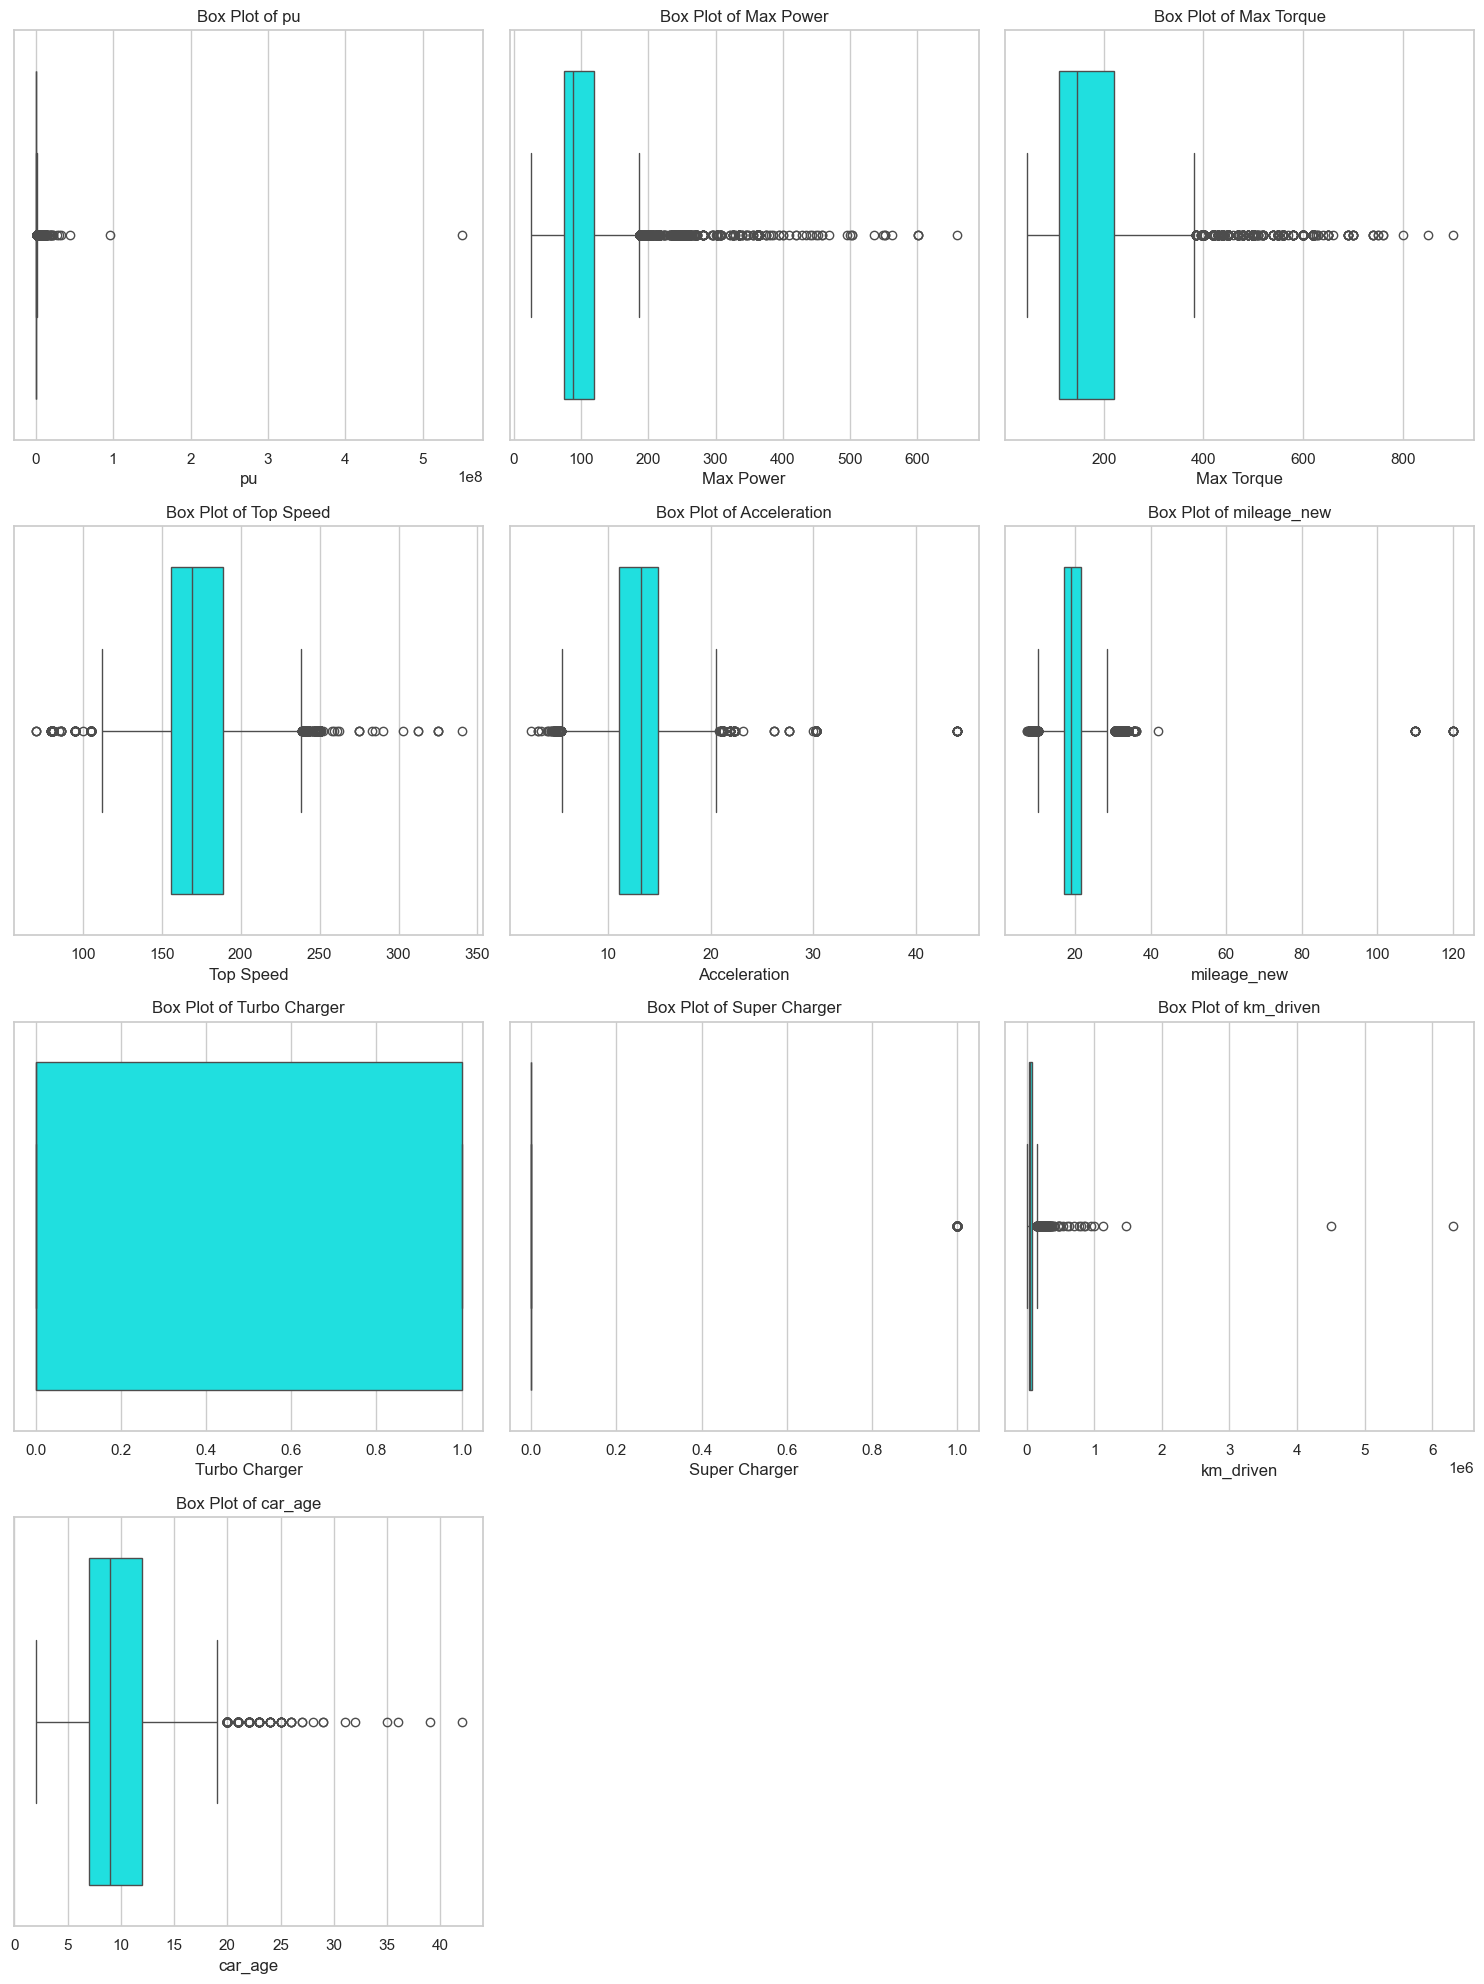

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (excluding boolean columns)
# Use select_dtypes to filter numeric columns (int, float) and exclude bool
numerical_data = X_train_clipped.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

# Print the numerical columns
print("Numerical Columns:")
print(numerical_data.columns.tolist())

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_data.columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X_train_clipped[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# --- BOX PLOTS ---
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

Although some features seem to have skewness i will be keeping them, as for example, old cars have a highr chance of using a manual gear, unlike new cars where the meta is using automatic. Moreover, using manual or automatic changes the potential acceleration, top speed, horse speed, and toqrue, so capturing the small noise may make a positive differencce 


for the price we solved the skewness problem by log tranforming and adding 1 to the value to not get into error due to cars that have a price of 0, some cas may have that price if they are for scrap parts 

In [39]:


# Scale features (fit on training, transform both sets)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clipped)
X_val_scaled = scaler.transform(X_val_clipped)


In [40]:


# Impute missing values (fit on training, transform both sets)
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_val_imputed = imputer.transform(X_val_scaled)



In [41]:

# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)


In [42]:
X_train_res.shape[0]

41638

In [43]:
import pickle
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file) # To save the variable into the `scaler.pkl` file.

import pickle
with open('imputer.pkl', 'wb') as file:
    pickle.dump(imputer, file) # To save the variable into the `scaler.pkl` file.

import pickle
with open('smote.pkl', 'wb') as file:
    pickle.dump(smote, file) # To save the variable into the `scaler.pkl` file.

# Selecting and Hyper Tuning/ Finetuning Machines Learning Model and Conducting Performance Analysis: 

# Model 1 
small number parameters, as i didnt use many hidden layers nor nuernos, i wanted to test if these kind of configiration works or not 
BatchNormalization helps mitigate issues like vanishing/exploding gradients and allows for faster convergence.

In [44]:

# Build the neural network
model = Sequential([
    Dense(64, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')  # Binary classification
])
model.summary()

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 3,937 (15.38 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4337 - loss: 0.9297 - val_accuracy: 0.3984 - val_loss: 0.7284
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4871 - loss: 0.8557 - val_accuracy: 0.4075 - val_loss: 0.7226
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5342 - loss: 0.7913 - val_accuracy: 0.4112 - val_loss: 0.7171
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5823 - loss: 0.7359 - val_accuracy: 0.4138 - val_loss: 0.7120
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6205 - loss: 0.6892 - val_accuracy: 0.4150 - val_loss: 0.7074
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6534 - loss: 0.6498 - val_accuracy: 0.4185 - val_loss: 0.7031
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6787 - loss: 0.6168 - val_accuracy: 0.4215 - val_loss: 0.6991
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7000 - loss: 0.5890 - val_accuracy: 0.4299 - v

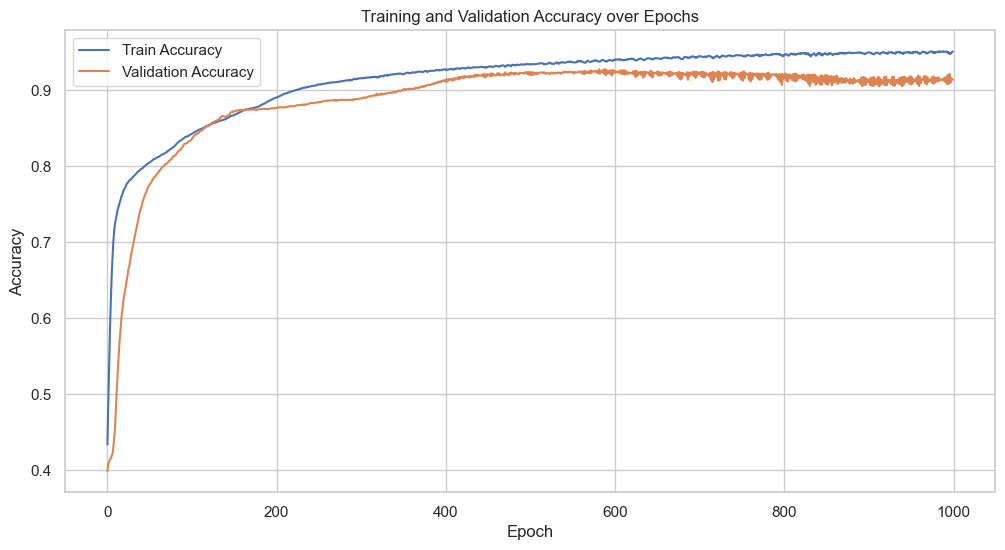

In [45]:
# Train the model with full-batch gradient descent (no mini-batches)
history = model.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9135
Precision: 0.9736
Recall: 0.9118
F1 Score: 0.9417


# Model 2 

In [47]:
from tensorflow.keras.layers import Dense, Dropout
# Model 2 
model2 = Sequential([
    Dense(64, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])
model2.summary()

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 3,937 (15.38 KB)

 Non-trainable params: 224 (896.00 B)

In [48]:
# Train the model with full-batch gradient descent (no mini-batches)
history2 = model2.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model2.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4504 - loss: 0.9770 - val_accuracy: 0.2737 - val_loss: 0.7928
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4867 - loss: 0.8974 - val_accuracy: 0.2749 - val_loss: 0.7835
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5279 - loss: 0.8244 - val_accuracy: 0.2747 - val_loss: 0.7745
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5641 - loss: 0.7682 - val_accuracy: 0.2760 - val_loss: 0.7659
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5949 - loss: 0.7257 - val_accuracy: 0.2781 - val_loss: 0.7576
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6225 - loss: 0.6864 - val_accuracy: 0.2812 - val_loss: 0.7497
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6430 - loss: 0.6541 - val_accuracy: 0.2866 - val_loss: 0.7422
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6677 - loss: 0.6263 - val_accuracy: 0.293

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9245
Precision: 0.9576
Recall: 0.9432
F1 Score: 0.9503


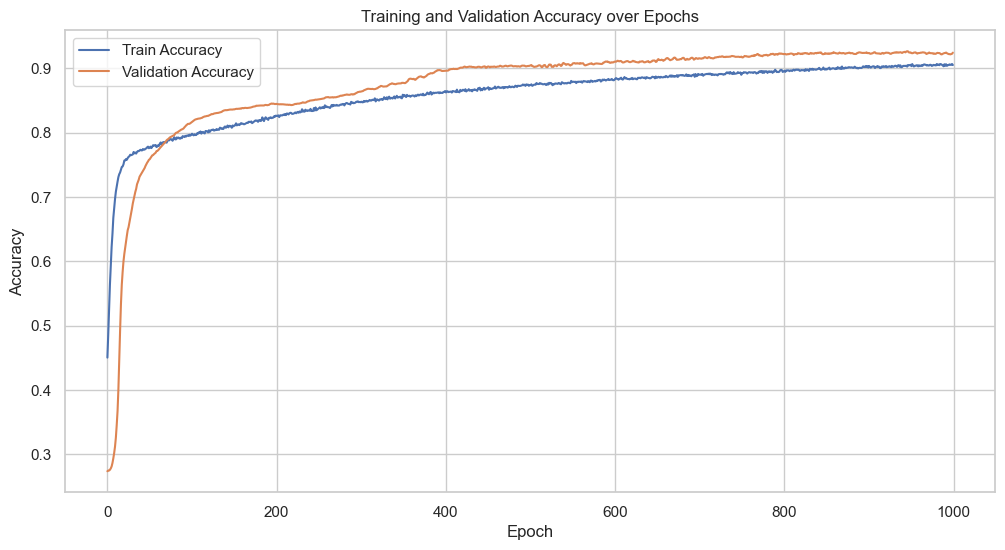

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model2.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

# Model 3

In [50]:
from tensorflow.keras.layers import Dense, Dropout
# Model 3
model3 = Sequential([
    Dense(128, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])
model3.summary()

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 12,993 (50.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [51]:
# Train the model with full-batch gradient descent (no mini-batches)
history3 = model3.fit(
    X_train_res, y_train_res,
    epochs=1200,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model3.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

Epoch 1/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6038 - loss: 0.7136 - val_accuracy: 0.7262 - val_loss: 0.6591
Epoch 2/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.6742 - loss: 0.6154 - val_accuracy: 0.7218 - val_loss: 0.6490
Epoch 3/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.7208 - loss: 0.5448 - val_accuracy: 0.7069 - val_loss: 0.6411
Epoch 4/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7440 - loss: 0.5085 - val_accuracy: 0.6965 - val_loss: 0.6348
Epoch 5/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7524 - loss: 0.4914 - val_accuracy: 0.6864 - val_loss: 0.6297
Epoch 6/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.7612 - loss: 0.4757 - val_accuracy: 0.6770 - val_loss: 0.6255
Epoch 7/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7631 - loss: 0.4677 - val_accuracy: 0.6674 - val_loss: 0.6222
Epoch 8/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7666 - loss: 0.4606 - val_accuracy: 0.658

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model3.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.9243
Precision: 0.9780
Recall: 0.9220
F1 Score: 0.9492


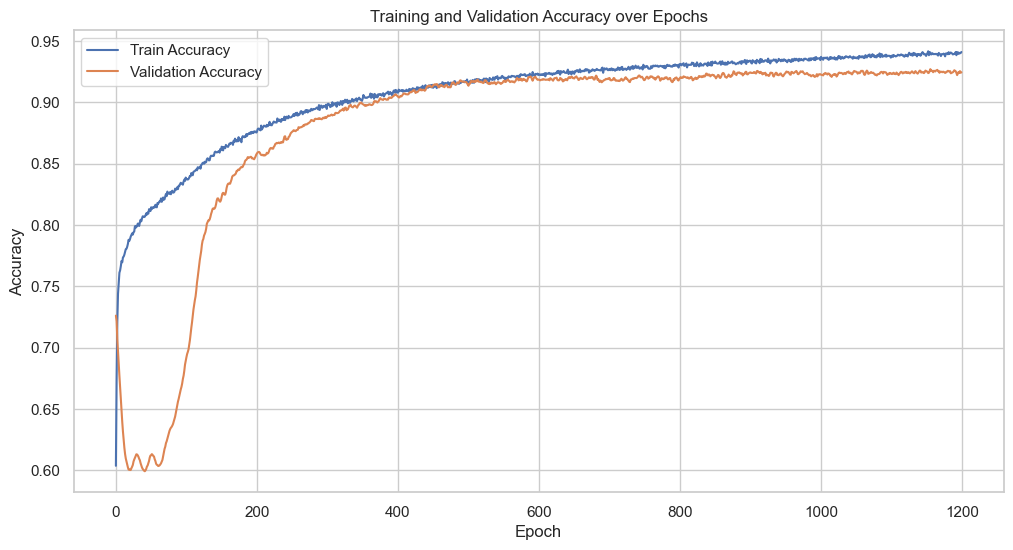

In [53]:
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

# Model 4

In [54]:
from tensorflow.keras.layers import Dense, Dropout
# Model 4 
model4 = Sequential([
    Dense(128, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])
model4.summary()

model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5229 - loss: 0.7238 - val_accuracy: 0.7535 - val_loss: 0.6665
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5700 - loss: 0.6847 - val_accuracy: 0.7530 - val_loss: 0.6623
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6224 - loss: 0.6490 - val_accuracy: 0.7710 - val_loss: 0.6575
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6524 - loss: 0.6210 - val_accuracy: 0.7832 - val_loss: 0.6517
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6796 - loss: 0.5942 - val_accuracy: 0.7672 - val_loss: 0.6453
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6980 - loss: 0.5750 - val_accuracy: 0.7617 - val_loss: 0.6386
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7129 - loss: 0.5561 - val_accuracy: 0.7566 - val_loss: 0.6320
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7218 - loss: 0.5400 - val_accuracy: 0.755

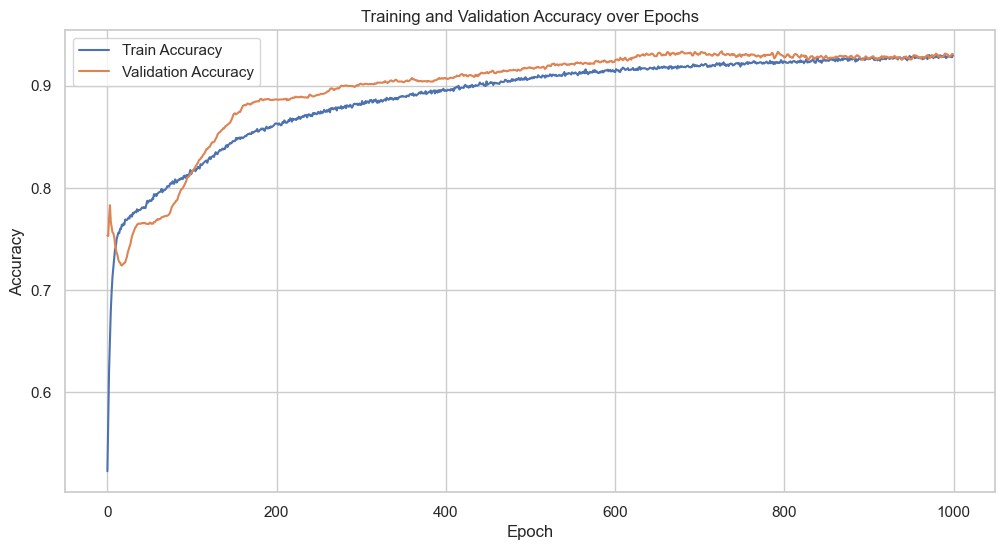

In [55]:
# Train the model with full-batch gradient descent (no mini-batches)
history4 = model4.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model4.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model4.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.9310
Precision: 0.9708
Recall: 0.9381
F1 Score: 0.9542


# Model 5

In [57]:
from tensorflow.keras.layers import Dense, Dropout
# Model 5
model5 = Sequential([
    Dense(32, input_dim=X_train_res.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])
model5.summary()

model5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step - accuracy: 0.4892 - loss: 0.8362 - val_accuracy: 0.7607 - val_loss: 0.6370
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4893 - loss: 0.8239 - val_accuracy: 0.7602 - val_loss: 0.6317
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4910 - loss: 0.8108 - val_accuracy: 0.7602 - val_loss: 0.6265
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4934 - loss: 0.7983 - val_accuracy: 0.7613 - val_loss: 0.6214
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4959 - loss: 0.7842 - val_accuracy: 0.7611 - val_loss: 0.6166
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4986 - loss: 0.7724 - val_accuracy: 0.7620 - val_loss: 0.6118
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4990 - loss: 0.7629 - val_accuracy: 0.7625 - val_loss: 0.6071
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5020 - loss: 0.7513 - val_accuracy: 0.7648 -

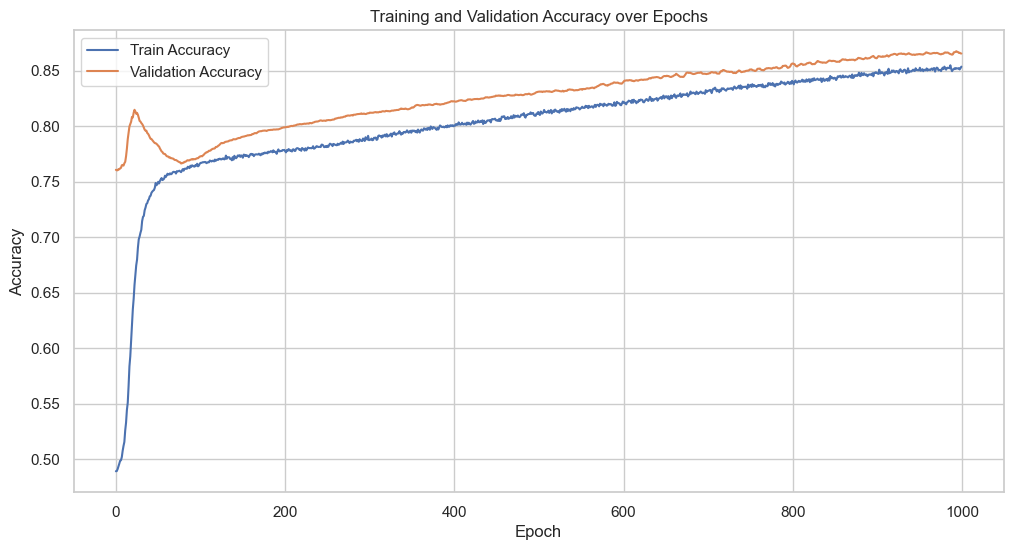

In [58]:
# Train the model with full-batch gradient descent (no mini-batches)
history5 = model5.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model5.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history5.history['accuracy'], label='Train Accuracy')
plt.plot(history5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model5.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step
Accuracy: 0.8654
Precision: 0.9532
Recall: 0.8669
F1 Score: 0.9080


# Model 6

In [60]:
from tensorflow.keras.layers import Dense, Dropout
# Model 6
model6 = Sequential([
    Dense(128, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])
model6.summary()

model6.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 12,993 (50.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5117 - loss: 0.8587 - val_accuracy: 0.4738 - val_loss: 0.6912
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5737 - loss: 0.7623 - val_accuracy: 0.5057 - val_loss: 0.6796
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6265 - loss: 0.6854 - val_accuracy: 0.5416 - val_loss: 0.6694
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6618 - loss: 0.6427 - val_accuracy: 0.5771 - val_loss: 0.6608
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6939 - loss: 0.6009 - val_accuracy: 0.6060 - val_loss: 0.6536
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7084 - loss: 0.5738 - val_accuracy: 0.6214 - val_loss: 0.6473
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7260 - loss: 0.5497 - val_accuracy: 0.6351 - val_loss: 0.6415
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7359 - loss: 0.5365 - val_accuracy: 0.646

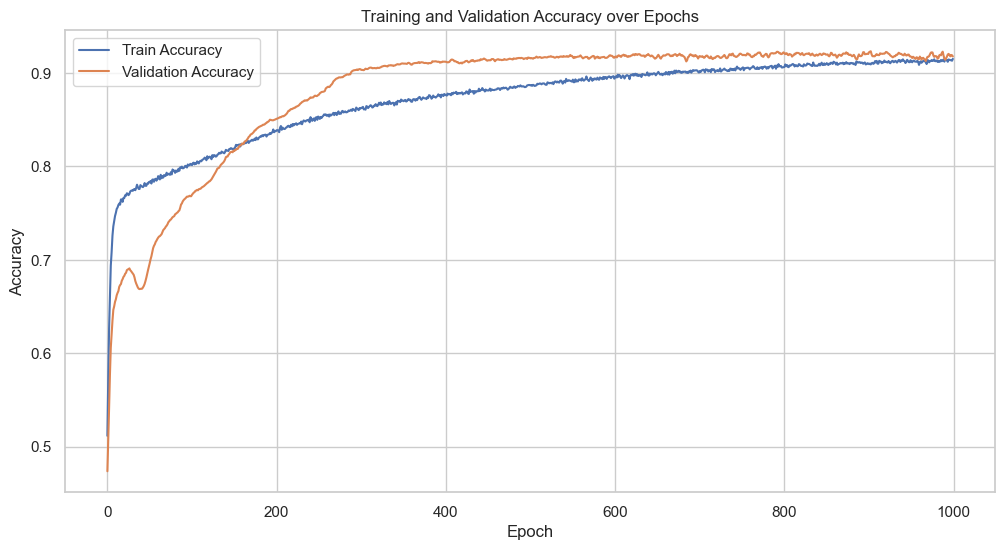

In [61]:
# Train the model with full-batch gradient descent (no mini-batches)
history6 = model6.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model6.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history6.history['accuracy'], label='Train Accuracy')
plt.plot(history6.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model6.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9177
Precision: 0.9709
Recall: 0.9202
F1 Score: 0.9449


# Model 7

In [63]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
# Model 7
model7 = Sequential([
    Dense(512, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),   
    Dropout(0.1),
    Dense(64, activation='relu'),
    BatchNormalization(),   
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),   
    Dropout(0.1),
    Dense(8, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')  # Binary classification
])
model7.summary()

model7.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\Kaz4n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,537 (732.57 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 2,000 (7.81 KB)

Epoch 1/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4663 - loss: 6.0239 - val_accuracy: 0.4103 - val_loss: 5.7373
Epoch 2/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - accuracy: 0.6525 - loss: 5.6900 - val_accuracy: 0.5627 - val_loss: 5.6448
Epoch 3/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step - accuracy: 0.7194 - loss: 5.5131 - val_accuracy: 0.6379 - val_loss: 5.5423
Epoch 4/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.7427 - loss: 5.3858 - val_accuracy: 0.6699 - val_loss: 5.4346
Epoch 5/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step - accuracy: 0.7545 - loss: 5.2655 - val_accuracy: 0.6930 - val_loss: 5.3245
Epoch 6/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step - accuracy: 0.7597 - loss: 5.1474 - val_accuracy: 0.7053 - val_loss: 5.2128
Epoch 7/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step - accuracy: 0.7642 - loss: 5.0300 - val_accuracy: 0.7118 - val_loss: 5.1004
Epoch 8/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 0.7642 - loss: 4.9164 - val_accuracy: 0.7144 - val_

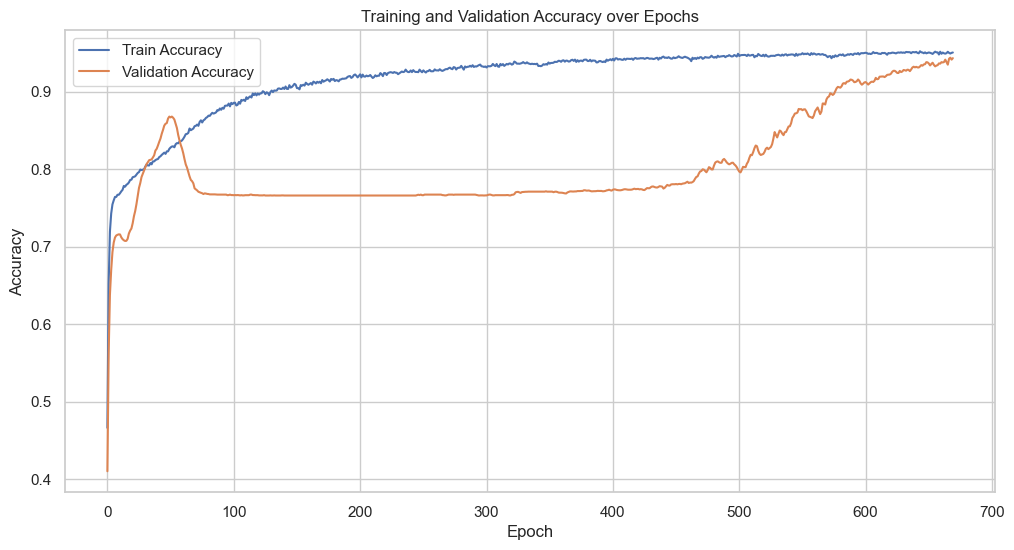

In [64]:
# Train the model with full-batch gradient descent (no mini-batches)
history7 = model7.fit(
    X_train_res, y_train_res,
    epochs=670,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model7.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history7.history['accuracy'], label='Train Accuracy')
plt.plot(history7.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on validation set
y_pred_prob = model7.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)  # Calculate F1 score

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9431
Precision: 0.9447
Recall: 0.9833
F1 Score: 0.9636


# For the model selection approach, i tried to have the smallest sized model(Size of Parameters) with the most best performance metrics we measure(accuracy, precision, recall, F1-Score), therefore i tried different sized models, we could adjust the models size by choosing different hidden layers count and nuerons ount, like "model"( Total params: 4,161), "model2" ( Total params: 4,161) and "model5" ( Total params: 1,089) which had small number of nuerons and hidden layers, while also trying a relativly huge model like, "model7" (187,537 total parameters). also i tried medium sized models like "model3" (Total params: 13,441), "model4" (Total params: 13,825)

so after seeing how balanced the metrics we choose(accuracy, precision, recall and F1-Score) with the model size i choose model 6 as it delivers close performance to the best performance model (model 7) and i has 14x less model size, while the smalleset model (model 5) delivers less performance compared to model 6, so i choose model 6 as the best model as its the sweet spot best models leveraging a small size with good performnace 

# Overview of the Graph for the model 6
1. The graph shows the training accuracy (blue line) and validation accuracy (orange line) over epochs.
Both lines start at low accuracy (~0.5) and increase as the number of epochs increases.
After approximately 200 epochs, both lines plateau, indicating that the model has converged.
2. Key Observations
a. Initial Phase (Epochs 0–200):
Both the training and validation accuracies increase rapidly during this phase.
This suggests that the model is learning effectively from the data and generalizing well to the validation set initially.
b. Plateau Phase (After ~200 Epochs):
Both lines plateau, indicating that further training does not significantly improve the model's performance.
The validation accuracy stabilizes around 0.92 , which is a high value, suggesting good generalization.
c. Comparison Between Training and Validation Accuracy:
The training accuracy is consistently slightly higher than the validation accuracy throughout the training process.
However, the gap between the two is relatively small and does not widen significantly as training progresses. This indicates that the model is not overfitting excessively.
3. Analysis of Potential Problems
a. Overfitting:
Overfitting occurs when the model performs well on the training data but poorly on the validation or test data. In this case:
The validation accuracy remains close to the training accuracy throughout the training process.
There is no significant divergence between the two curves, which suggests that overfitting is not a major issue.
b. Underfitting:
Underfitting occurs when the model fails to learn the underlying patterns in the data, resulting in poor performance on both training and validation sets. Here:
Both the training and validation accuracies reach high values (>0.9), indicating that the model has learned the data sufficiently.
Therefore, underfitting is not an issue.


In [66]:

# save best performance model
model6.save('trained_model.keras')

